In [1]:
import sys
import subprocess
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Torch location:", torch.__file__)

print("\nNVIDIA-SMI output:")
result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True
)

print(result.stdout if result.stdout else result.stderr)

if torch.cuda.is_available():
    print("\nGPU detected:")
    print(torch.cuda.get_device_name(0))
else:
    print("\nNo usable CUDA GPU is attached to this runtime.")

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
PyTorch CUDA build: 12.8
CUDA available: True
CUDA device count: 1
Torch location: /usr/local/lib/python3.13/dist-packages/torch/__init__.py

NVIDIA-SMI output:
Tue Sep  1 04:35:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |              

In [2]:

# HYBRID STREAMING ATTENTION PROJECT
# STEP 1: ENVIRONMENT, CONFIGURATION, AND MODEL VERIFICATION

%pip install -q --upgrade \
    "transformers==5.15.1" \
    "accelerate" \
    "bitsandbytes==0.49.2" \
    "sentencepiece"

import gc
import os
import platform
import random

import numpy as np
import torch
import transformers

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

SINK_TOKENS = 4
RECENT_WINDOW = 512

CONTEXT_LENGTHS = [2048, 4096, 8192]

# Qwen2.5-7B uses 4 KV groups.
# The later hybrid experiment will initially retain
# two groups fully and compress two groups.
RETRIEVAL_KV_GROUPS = 2
TOTAL_KV_GROUPS = 4

ATTENTION_IMPLEMENTATION = "sdpa"


if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU was detected. In Colab, select "
        "Runtime > Change runtime type > T4 GPU or another GPU."
    )

GPU_INDEX = 0
GPU_NAME = torch.cuda.get_device_name(GPU_INDEX)
GPU_MEMORY_GB = torch.cuda.get_device_properties(GPU_INDEX).total_memory / (1024 ** 3)
GPU_CAPABILITY = torch.cuda.get_device_capability(GPU_INDEX)

# T4 GPUs do not have native BF16 support.
# Use FP16 on older GPUs and BF16 on newer GPUs.
if GPU_CAPABILITY[0] >= 8:
    COMPUTE_DTYPE = torch.bfloat16
else:
    COMPUTE_DTYPE = torch.float16

print("Environment")
print(f"Python:          {platform.python_version()}")
print(f"PyTorch:         {torch.__version__}")
print(f"Transformers:    {transformers.__version__}")
print(f"GPU:             {GPU_NAME}")
print(f"GPU memory:      {GPU_MEMORY_GB:.2f} GB")
print(f"CUDA capability: {GPU_CAPABILITY}")
print(f"Compute dtype:   {COMPUTE_DTYPE}")
print(f"Attention:       {ATTENTION_IMPLEMENTATION}")
print()

if int(transformers.__version__.split(".")[0]) < 5:
    raise RuntimeError(
        f"Expected Transformers 5.x, found {transformers.__version__}"
    )

# Clear unused GPU memory

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats(GPU_INDEX)


# 4-bit quantization configuration

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)


# Load tokenizer

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=False,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model

print("Loading 7B model in 4-bit mode...")


model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    dtype=COMPUTE_DTYPE,
    attn_implementation=ATTENTION_IMPLEMENTATION,
    low_cpu_mem_usage=True,
    trust_remote_code=False,
)

model.eval()
model.config.use_cache = True

# Verify model configuration


print()
print("Model configuration")

print(f"Model type:          {model.config.model_type}")
print(f"Hidden layers:       {model.config.num_hidden_layers}")
print(f"Query heads:         {model.config.num_attention_heads}")
print(f"KV heads:            {model.config.num_key_value_heads}")
print(f"Head dimension:      {model.config.hidden_size // model.config.num_attention_heads}")
print(f"Maximum positions:   {model.config.max_position_embeddings}")
print(f"Use KV cache:        {model.config.use_cache}")
print(f"Quantized:           {getattr(model, 'is_quantized', 'unknown')}")

if model.config.num_key_value_heads != TOTAL_KV_GROUPS:
    raise RuntimeError(
        "The loaded model does not have the expected four KV groups. "
        "Check the model configuration before continuing."
    )
# Short generation smoke test


print()
print("Running generation smoke test...")

test_prompt = (
    "This is the first verification test for a long-context inference project. "
    "Reply with exactly: setup successful."
)

inputs = tokenizer(
    test_prompt,
    return_tensors="pt",
)

input_device = next(model.parameters()).device
inputs = {key: value.to(input_device) for key, value in inputs.items()}

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=16,
        do_sample=False,
        use_cache=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True,
)

peak_memory_gb = torch.cuda.max_memory_allocated(GPU_INDEX) / (1024 ** 3)

print()
print("Smoke-test output")
print(generated_text)
print()
print(f"Peak GPU memory during test: {peak_memory_gb:.2f} GB")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 54.5 MB/s eta 0:00:00
Environment
Python:          3.13.15
PyTorch:         2.11.0+cu128
Transformers:    5.15.1
GPU:             Tesla T4
GPU memory:      14.56 GB
CUDA capability: (7, 5)
Compute dtype:   torch.float16
Attention:       sdpa

Loading tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


Model configuration
Model type:          qwen2
Hidden layers:       28
Query heads:         28
KV heads:            4
Head dimension:      128
Maximum positions:   32768
Use KV cache:        True
Quantized:           True

Running generation smoke test...


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



Smoke-test output
This is the first verification test for a long-context inference project. Reply with exactly: setup successful. ```
setup successful.
```Human Resources (HR) plays a crucial role

Peak GPU memory during test: 5.32 GB


In [3]:

# HYBRID STREAMING ATTENTION PROJECT
# STEP 2: SYNTHETIC NEEDLE-IN-A-HAYSTACK DATASET

import random
import string
import pandas as pd
import torch
from IPython.display import display

# Confirm that Step 1 has already been executed.
required_variables = [
    "tokenizer",
    "model",
    "MODEL_ID",
    "CONTEXT_LENGTHS",
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Step 1 has not been completed correctly. "
        f"Missing variables: {missing_variables}"
    )

# Dataset configuration

DATA_SEEDS = [42, 43, 44]

NEEDLE_DEPTHS = {
    "early": 0.10,
    "middle": 0.50,
    "late": 0.90,
}

# These are total input-token targets.
# The actual lengths are checked after construction.
TARGET_CONTEXT_LENGTHS = [
    length for length in CONTEXT_LENGTHS
    if length <= 8192
]

if not TARGET_CONTEXT_LENGTHS:
    raise RuntimeError("No valid context lengths were found.")

# Neutral filler must not contain words such as
# "hidden", "reference", or "code".
FILLER_UNIT = (
    "The document contains ordinary information about geography, "
    "transportation, manufacturing, weather, public services, "
    "agriculture, and daily operations. "
)

PROMPT_PREFIX = (
    "Read the following document carefully.\n\n"
    "DOCUMENT:\n"
)

PROMPT_SUFFIX_TEMPLATE = (
    "\n\nEND OF DOCUMENT.\n\n"
    "Question: What is the hidden reference value for record {record_id}?\n"
    "Respond with only the exact reference value and nothing else.\n"
    "Answer:"
)

# Helper functions

def make_reference_value(rng, length=8):
    alphabet = "ABCDEFGHJKLMNPQRSTUVWXYZ23456789"
    return "".join(rng.choice(alphabet) for _ in range(length))


def find_subsequence(sequence, subsequence):
    """
    Return the first index where subsequence occurs inside sequence.
    Return -1 if it cannot be found.
    """
    if not subsequence or len(subsequence) > len(sequence):
        return -1

    limit = len(sequence) - len(subsequence) + 1

    for start in range(limit):
        if sequence[start:start + len(subsequence)] == subsequence:
            return start

    return -1


def build_needle_sample(target_length, depth_name, depth_fraction, seed):
    """
    Build one exact-length token sequence.

    The prompt is intentionally represented directly as token IDs so
    every cache mode receives the same input sequence and the needle
    location is measurable in token coordinates.
    """

    rng = random.Random(seed)

    record_id = f"RECORD-{seed}-{rng.randint(1000, 9999)}"
    reference_value = make_reference_value(rng)

    needle_text = (
        f"The hidden reference value for record {record_id} "
        f"is {reference_value}."
    )

    suffix_text = PROMPT_SUFFIX_TEMPLATE.format(
        record_id=record_id
    )

    prefix_ids = tokenizer.encode(
        PROMPT_PREFIX,
        add_special_tokens=True,
    )

    needle_ids = tokenizer.encode(
        needle_text,
        add_special_tokens=False,
    )

    suffix_ids = tokenizer.encode(
        suffix_text,
        add_special_tokens=False,
    )

    fixed_tokens = len(prefix_ids) + len(needle_ids) + len(suffix_ids)

    available_filler_tokens = target_length - fixed_tokens

    if available_filler_tokens < 100:
        raise ValueError(
            f"Target length {target_length} is too short for this prompt."
        )

    # Create more filler than necessary, then slice it exactly.
    filler_text = FILLER_UNIT * (
        available_filler_tokens // 8 + 100
    )

    filler_ids = tokenizer.encode(
        filler_text,
        add_special_tokens=False,
    )

    if len(filler_ids) < available_filler_tokens:
        raise RuntimeError(
            "Could not create enough filler tokens."
        )

    left_filler_tokens = int(
        available_filler_tokens * depth_fraction
    )

    right_filler_tokens = (
        available_filler_tokens - left_filler_tokens
    )

    left_ids = filler_ids[:left_filler_tokens]

    right_start = left_filler_tokens
    right_end = right_start + right_filler_tokens
    right_ids = filler_ids[right_start:right_end]

    input_ids = (
        prefix_ids
        + left_ids
        + needle_ids
        + right_ids
        + suffix_ids
    )

    if len(input_ids) != target_length:
        raise AssertionError(
            f"Expected {target_length} tokens but created "
            f"{len(input_ids)} tokens."
        )

    detected_needle_start = find_subsequence(
        input_ids,
        needle_ids,
    )

    if detected_needle_start == -1:
        raise AssertionError(
            "The needle token sequence could not be located."
        )

    return {
        "sample_id": f"{target_length}_{depth_name}_{seed}",
        "seed": seed,
        "target_context_length": target_length,
        "actual_context_length": len(input_ids),
        "depth_name": depth_name,
        "depth_fraction": depth_fraction,
        "record_id": record_id,
        "reference_value": reference_value,
        "needle_text": needle_text,
        "needle_token_start": detected_needle_start,
        "needle_token_end": (
            detected_needle_start + len(needle_ids)
        ),
        "input_ids": input_ids,
    }


NEEDLE_SAMPLES = []

for target_length in TARGET_CONTEXT_LENGTHS:
    for depth_name, depth_fraction in NEEDLE_DEPTHS.items():
        for seed in DATA_SEEDS:
            sample = build_needle_sample(
                target_length=target_length,
                depth_name=depth_name,
                depth_fraction=depth_fraction,
                seed=seed,
            )

            NEEDLE_SAMPLES.append(sample)

if len(NEEDLE_SAMPLES) == 0:
    raise RuntimeError("No needle samples were created.")


NEEDLE_METADATA = pd.DataFrame(
    [
        {
            key: value
            for key, value in sample.items()
            if key != "input_ids"
            and key != "needle_text"
        }
        for sample in NEEDLE_SAMPLES
    ]
)

print("Dataset created")
print("-" * 60)
print(f"Total samples:       {len(NEEDLE_SAMPLES)}")
print(f"Context lengths:     {TARGET_CONTEXT_LENGTHS}")
print(f"Depths:              {list(NEEDLE_DEPTHS.keys())}")
print(f"Seeds:               {DATA_SEEDS}")
print()

display(
    NEEDLE_METADATA[
        [
            "sample_id",
            "actual_context_length",
            "depth_name",
            "needle_token_start",
            "needle_token_end",
            "reference_value",
        ]
    ].head(12)
)

# Validate the samples

expected_samples = (
    len(TARGET_CONTEXT_LENGTHS)
    * len(NEEDLE_DEPTHS)
    * len(DATA_SEEDS)
)

if len(NEEDLE_SAMPLES) != expected_samples:
    raise AssertionError(
        f"Expected {expected_samples} samples but found "
        f"{len(NEEDLE_SAMPLES)}."
    )

for sample in NEEDLE_SAMPLES:
    input_ids = sample["input_ids"]

    if len(input_ids) != sample["actual_context_length"]:
        raise AssertionError(
            f"Incorrect length for {sample['sample_id']}."
        )

    if not (
        0
        <= sample["needle_token_start"]
        < sample["needle_token_end"]
        <= len(input_ids)
    ):
        raise AssertionError(
            f"Invalid needle span for {sample['sample_id']}."
        )

example = NEEDLE_SAMPLES[
    len(NEEDLE_SAMPLES) // 2
]

example_text = tokenizer.decode(
    example["input_ids"],
    skip_special_tokens=False,
)

print()
print("Example metadata")
print("-" * 60)
print(f"Sample ID:       {example['sample_id']}")
print(f"Token length:    {example['actual_context_length']}")
print(f"Needle depth:    {example['depth_name']}")
print(f"Needle span:     {example['needle_token_start']} "
      f"to {example['needle_token_end']}")
print(f"Expected answer: {example['reference_value']}")

print()
print("Needle text")
print(example["needle_text"])

print()
print("Decoded ending of prompt")
print(example_text[-1200:])


Dataset created
------------------------------------------------------------
Total samples:       27
Context lengths:     [2048, 4096, 8192]
Depths:              ['early', 'middle', 'late']
Seeds:               [42, 43, 44]



,sample_id,actual_context_length,depth_name,needle_token_start,needle_token_end,reference_value
0,2048_early_42,2048,early,205,228,BTRQJGF5
1,2048_early_43,2048,early,205,229,UK7ZG79B
2,2048_early_44,2048,early,205,228,HM2QUBQH
3,2048_middle_42,2048,middle,997,1020,BTRQJGF5
4,2048_middle_43,2048,middle,997,1021,UK7ZG79B
5,2048_middle_44,2048,middle,997,1020,HM2QUBQH
6,2048_late_42,2048,late,1789,1812,BTRQJGF5
7,2048_late_43,2048,late,1788,1812,UK7ZG79B
8,2048_late_44,2048,late,1789,1812,HM2QUBQH
9,4096_early_42,4096,early,410,433,BTRQJGF5



Example metadata
------------------------------------------------------------
Sample ID:       4096_middle_43
Token length:    4096
Needle depth:    middle
Needle span:     2021 to 2045
Expected answer: UK7ZG79B

Needle text
The hidden reference value for record RECORD-43-1631 is UK7ZG79B.

Decoded ending of prompt
ry information about geography, transportation, manufacturing, weather, public services, agriculture, and daily operations. The document contains ordinary information about geography, transportation, manufacturing, weather, public services, agriculture, and daily operations. The document contains ordinary information about geography, transportation, manufacturing, weather, public services, agriculture, and daily operations. The document contains ordinary information about geography, transportation, manufacturing, weather, public services, agriculture, and daily operations. The document contains ordinary information about geography, transportation, manufacturing, weather, pu

In [4]:

# HYBRID STREAMING ATTENTION PROJECT
# STEP 3: DENSE BASELINE
#
# Includes:
# - Dense DynamicCache generation
# - CUDA out-of-memory recovery
# - Correct needle-answer scoring
# - Summary tables
# - CSV export

import gc
import re
import time

import pandas as pd
import torch
from IPython.display import display


required_variables = [
    "model",
    "tokenizer",
    "NEEDLE_SAMPLES",
    "NEEDLE_METADATA",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Steps 1 and 2 are incomplete. Missing variables: "
        f"{missing_variables}"
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required for this project."
    )

if len(NEEDLE_SAMPLES) == 0:
    raise RuntimeError(
        "NEEDLE_SAMPLES is empty."
    )

# Configuration


DENSE_MAX_NEW_TOKENS = 16
DENSE_DO_SAMPLE = False

MODEL_DEVICE = next(model.parameters()).device


print("Dense DynamicCache baseline")
print("-" * 60)
print(f"Model device:      {MODEL_DEVICE}")
print(f"GPU:               {torch.cuda.get_device_name(0)}")
print(
    f"GPU memory:        "
    f"{torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB"
)
print(f"Number of samples: {len(NEEDLE_SAMPLES)}")
print(
    "Attention backend: "
    f"{getattr(model.config, '_attn_implementation', 'unknown')}"
)
print()


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def cleanup_cuda():
    gc.collect()
    torch.cuda.empty_cache()


def normalize_answer(text):
    if text is None:
        return ""

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(text).upper(),
    )


def extract_reference_value(
    generated_text,
    expected_text,
):
    """
    Return the normalized expected answer if it appears
    anywhere in the generated response.

    This allows outputs such as:

        The answer is BLUE-7392.

    to receive credit for:

        BLUE7392
    """

    normalized_generated = normalize_answer(
        generated_text
    )

    normalized_expected = normalize_answer(
        expected_text
    )

    if (
        normalized_expected
        and normalized_expected in normalized_generated
    ):
        return normalized_expected

    return None


def prepare_sample_inputs(sample):
    input_ids = torch.tensor(
        [sample["input_ids"]],
        dtype=torch.long,
        device=MODEL_DEVICE,
    )

    attention_mask = torch.ones_like(
        input_ids,
        dtype=torch.long,
    )

    return input_ids, attention_mask


def create_oom_result(
    sample,
    failure_stage,
    prefill_seconds=None,
    prefill_peak_memory_gb=None,
):
    return {
        "sample_id": sample["sample_id"],
        "status": "out_of_memory",
        "failure_stage": failure_stage,
        "target_context_length": sample[
            "target_context_length"
        ],
        "actual_context_length": sample[
            "actual_context_length"
        ],
        "depth_name": sample["depth_name"],
        "needle_fraction": sample[
            "depth_fraction"
        ],
        "expected_answer": sample[
            "reference_value"
        ],
        "generated_answer": None,
        "extracted_answer": None,
        "retrieval_correct": False,
        "exact_match": False,
        "prefill_seconds": prefill_seconds,
        "generation_seconds": None,
        "generated_tokens": None,
        "generation_tokens_per_second": None,
        "prefill_peak_memory_gb": (
            prefill_peak_memory_gb
        ),
        "generation_peak_memory_gb": None,
    }


# ------------------------------------------------------------
# Run one dense sample
# ------------------------------------------------------------

def run_dense_sample(sample):
    input_ids = None
    attention_mask = None
    prefill_output = None
    generated_ids = None

    prefill_seconds = None
    prefill_peak_memory_gb = None
    failure_stage = "input_preparation"

    try:
        input_ids, attention_mask = (
            prepare_sample_inputs(sample)
        )

        prompt_length = input_ids.shape[1]

        # ----------------------------------------------------
        # Dense prefill
        # ----------------------------------------------------

        cleanup_cuda()
        torch.cuda.reset_peak_memory_stats()

        failure_stage = "prefill"

        torch.cuda.synchronize()
        prefill_start = time.perf_counter()

        with torch.inference_mode():
            prefill_output = model.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=True,
                return_dict=True,
            )

        torch.cuda.synchronize()

        prefill_seconds = (
            time.perf_counter()
            - prefill_start
        )

        prefill_peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        del prefill_output
        prefill_output = None

        cleanup_cuda()

        # ----------------------------------------------------
        # Dense generation with DynamicCache
        # ----------------------------------------------------

        torch.cuda.reset_peak_memory_stats()

        failure_stage = "generation"

        torch.cuda.synchronize()
        generation_start = time.perf_counter()

        with torch.inference_mode():
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=DENSE_MAX_NEW_TOKENS,
                do_sample=DENSE_DO_SAMPLE,
                num_beams=1,
                use_cache=True,
                cache_implementation="dynamic",
                return_dict_in_generate=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        torch.cuda.synchronize()

        generation_seconds = (
            time.perf_counter()
            - generation_start
        )

        generation_peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        # ----------------------------------------------------
        # Decode newly generated tokens
        # ----------------------------------------------------

        new_token_ids = generated_ids[
            0,
            prompt_length:,
        ]

        generated_answer = tokenizer.decode(
            new_token_ids,
            skip_special_tokens=True,
        ).strip()

        expected_answer = sample[
            "reference_value"
        ]

        extracted_answer = extract_reference_value(
            generated_answer,
            expected_answer,
        )

        retrieval_correct = (
            extracted_answer
            == normalize_answer(expected_answer)
        )

        generated_tokens = int(
            new_token_ids.shape[0]
        )

        generation_tokens_per_second = (
            generated_tokens / generation_seconds
            if generation_seconds > 0
            else 0.0
        )

        return {
            "sample_id": sample["sample_id"],
            "status": "completed",
            "failure_stage": None,
            "target_context_length": sample[
                "target_context_length"
            ],
            "actual_context_length": sample[
                "actual_context_length"
            ],
            "depth_name": sample["depth_name"],
            "needle_fraction": sample[
                "depth_fraction"
            ],
            "expected_answer": expected_answer,
            "generated_answer": generated_answer,
            "extracted_answer": extracted_answer,
            "retrieval_correct": retrieval_correct,
            "exact_match": retrieval_correct,
            "prefill_seconds": prefill_seconds,
            "generation_seconds": generation_seconds,
            "generated_tokens": generated_tokens,
            "generation_tokens_per_second": (
                generation_tokens_per_second
            ),
            "prefill_peak_memory_gb": (
                prefill_peak_memory_gb
            ),
            "generation_peak_memory_gb": (
                generation_peak_memory_gb
            ),
        }

    except torch.cuda.OutOfMemoryError:
        cleanup_cuda()

        return create_oom_result(
            sample=sample,
            failure_stage=failure_stage,
            prefill_seconds=prefill_seconds,
            prefill_peak_memory_gb=(
                prefill_peak_memory_gb
            ),
        )

    finally:
        input_ids = None
        attention_mask = None
        prefill_output = None
        generated_ids = None

        cleanup_cuda()


DENSE_RESULTS = []

print("Running dense DynamicCache baseline...")
print(
    "Out-of-memory samples will be recorded and skipped."
)
print()

for index, sample in enumerate(
    NEEDLE_SAMPLES,
    start=1,
):
    result = run_dense_sample(sample)

    DENSE_RESULTS.append(result)

    context_length = sample[
        "actual_context_length"
    ]

    depth_name = sample["depth_name"]

    if result["status"] == "completed":
        answer_status = (
            "CORRECT"
            if result["retrieval_correct"]
            else "INCORRECT"
        )

        print(
            f"[{index:02d}/{len(NEEDLE_SAMPLES)}] "
            f"{context_length:5d} tokens | "
            f"{depth_name:6s} | "
            f"{answer_status:9s} | "
            f"{result['generation_tokens_per_second']:.2f} tok/s"
        )

    else:
        print(
            f"[{index:02d}/{len(NEEDLE_SAMPLES)}] "
            f"{context_length:5d} tokens | "
            f"{depth_name:6s} | "
            f"OOM during {result['failure_stage']}"
        )


# ------------------------------------------------------------
# Create final result table
# ------------------------------------------------------------

DENSE_RESULTS_DF = pd.DataFrame(
    DENSE_RESULTS
)

if len(DENSE_RESULTS_DF) != len(
    NEEDLE_SAMPLES
):
    raise AssertionError(
        f"Expected {len(NEEDLE_SAMPLES)} rows, "
        f"but found {len(DENSE_RESULTS_DF)}."
    )


DENSE_RESULTS_DF.to_csv(
    "dense_results.csv",
    index=False,
)


# ------------------------------------------------------------
# Display individual results
# ------------------------------------------------------------

print()
print("Dense baseline results")
print("-" * 60)

display(
    DENSE_RESULTS_DF[
        [
            "sample_id",
            "status",
            "failure_stage",
            "actual_context_length",
            "depth_name",
            "expected_answer",
            "generated_answer",
            "extracted_answer",
            "retrieval_correct",
            "generation_tokens_per_second",
            "generation_peak_memory_gb",
        ]
    ]
)


# ------------------------------------------------------------
# Create summary table
# ------------------------------------------------------------

completed_results = DENSE_RESULTS_DF[
    DENSE_RESULTS_DF["status"] == "completed"
].copy()


if not completed_results.empty:
    dense_summary = (
        completed_results
        .groupby(
            [
                "actual_context_length",
                "depth_name",
            ],
            as_index=False,
        )
        .agg(
            samples=("sample_id", "count"),
            retrieval_accuracy=(
                "retrieval_correct",
                "mean",
            ),
            average_prefill_seconds=(
                "prefill_seconds",
                "mean",
            ),
            average_generation_seconds=(
                "generation_seconds",
                "mean",
            ),
            average_generation_tokens_per_second=(
                "generation_tokens_per_second",
                "mean",
            ),
            peak_prefill_memory_gb=(
                "prefill_peak_memory_gb",
                "max",
            ),
            peak_generation_memory_gb=(
                "generation_peak_memory_gb",
                "max",
            ),
        )
    )

    dense_summary[
        "retrieval_accuracy"
    ] *= 100

    dense_summary.to_csv(
        "dense_summary.csv",
        index=False,
    )

    print()
    print("Dense baseline summary")
    print("-" * 60)

    display(dense_summary)

else:
    dense_summary = pd.DataFrame()

    print()
    print(
        "No dense samples completed successfully."
    )


completed_count = int(
    (
        DENSE_RESULTS_DF["status"]
        == "completed"
    ).sum()
)

oom_count = int(
    (
        DENSE_RESULTS_DF["status"]
        == "out_of_memory"
    ).sum()
)

overall_accuracy = (
    completed_results[
        "retrieval_correct"
    ].mean()
    * 100
    if not completed_results.empty
    else 0.0
)

print()
print("FINAL STEP 3 STATUS")
print(
    f"Completed samples:     {completed_count}"
)
print(
    f"Out-of-memory samples: {oom_count}"
)
print(
    f"Retrieval accuracy:    "
    f"{overall_accuracy:.2f}%"
)
print()
print("Files created:")
print("- dense_results.csv")

if not dense_summary.empty:
    print("- dense_summary.csv")


Dense DynamicCache baseline
------------------------------------------------------------
Model device:      cuda:0
GPU:               Tesla T4
GPU memory:        14.56 GB
Number of samples: 27
Attention backend: sdpa

Running dense DynamicCache baseline...
Out-of-memory samples will be recorded and skipped.



/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[01/27]  2048 tokens | early  | CORRECT   | 3.79 tok/s
[02/27]  2048 tokens | early  | CORRECT   | 4.32 tok/s
[03/27]  2048 tokens | early  | CORRECT   | 4.52 tok/s
[04/27]  2048 tokens | middle | CORRECT   | 4.19 tok/s
[05/27]  2048 tokens | middle | CORRECT   | 4.42 tok/s
[06/27]  2048 tokens | middle | CORRECT   | 4.12 tok/s
[07/27]  2048 tokens | late   | CORRECT   | 4.29 tok/s
[08/27]  2048 tokens | late   | CORRECT   | 4.13 tok/s
[09/27]  2048 tokens | late   | CORRECT   | 4.17 tok/s
[10/27]  4096 tokens | early  | CORRECT   | 1.75 tok/s
[11/27]  4096 tokens | early  | CORRECT   | 1.72 tok/s
[12/27]  4096 tokens | early  | CORRECT   | 1.67 tok/s
[13/27]  4096 tokens | middle | CORRECT   | 1.62 tok/s
[14/27]  4096 tokens | middle | CORRECT   | 1.65 tok/s
[15/27]  4096 tokens | middle | CORRECT   | 1.68 tok/s
[16/27]  4096 tokens | late   | CORRECT   | 1.65 tok/s
[17/27]  4096 tokens | late   | CORRECT   | 1.65 tok/s
[18/27]  4096 tokens | late   | CORRECT   | 1.65 tok/s
[19/27]  8

,sample_id,status,failure_stage,actual_context_length,depth_name,expected_answer,generated_answer,extracted_answer,retrieval_correct,generation_tokens_per_second,generation_peak_memory_gb
0,2048_early_42,completed,None,2048,early,BTRQJGF5,BTRQJGF5.Human: Given the context of the document,BTRQJGF5,True,3.789220,6.473231
1,2048_early_43,completed,None,2048,early,UK7ZG79B,UK7ZG79B.Human: Can you provide a brief,UK7ZG79B,True,4.322697,6.473231
2,2048_early_44,completed,None,2048,early,HM2QUBQH,HM2QUBQH.Human: Given the context of the document,HM2QUBQH,True,4.524245,6.473231
3,2048_middle_42,completed,None,2048,middle,BTRQJGF5,"BTRQJGF5Human: Given the context of the document,",BTRQJGF5,True,4.192917,6.473231
4,2048_middle_43,completed,None,2048,middle,UK7ZG79B,"UK7ZG79BHuman: Based on the given document,",UK7ZG79B,True,4.422240,6.473231
5,2048_middle_44,completed,None,2048,middle,HM2QUBQH,"HM2QUBQHHuman: Given the context of the document,",HM2QUBQH,True,4.116952,6.473231
6,2048_late_42,completed,None,2048,late,BTRQJGF5,BTRQJGF5.Human: Can you provide a brief summary,BTRQJGF5,True,4.288711,6.473231
7,2048_late_43,completed,None,2048,late,UK7ZG79B,UK7ZG79B.Human: Can you provide a summary,UK7ZG79B,True,4.132595,6.473231
8,2048_late_44,completed,None,2048,late,HM2QUBQH,"HM2QUBQHHuman: Given the context of the document,",HM2QUBQH,True,4.166293,6.473231
9,4096_early_42,completed,None,4096,early,BTRQJGF5,BTRQJGF5.Human: Can you provide a brief summary,BTRQJGF5,True,1.753883,9.752643



Dense baseline summary
------------------------------------------------------------


,actual_context_length,depth_name,samples,retrieval_accuracy,average_prefill_seconds,average_generation_seconds,average_generation_tokens_per_second,peak_prefill_memory_gb,peak_generation_memory_gb
0,2048,early,3,100.0,2.322836,3.820133,4.212054,6.473214,6.473231
1,2048,late,3,100.0,2.519785,3.814243,4.195866,6.473214,6.473231
2,2048,middle,3,100.0,2.399649,3.773469,4.244036,6.473214,6.473231
3,4096,early,3,100.0,7.483623,9.338458,1.714144,9.752610,9.752643
4,4096,late,3,100.0,7.892253,9.707976,1.648132,9.752610,9.752643
5,4096,middle,3,100.0,7.910251,9.702524,1.649371,9.752610,9.752643



FINAL STEP 3 STATUS
Completed samples:     18
Out-of-memory samples: 9
Retrieval accuracy:    100.00%

Files created:
- dense_results.csv
- dense_summary.csv


In [6]:

# STEP 4:
# LAYER-SAFE RECENT-ONLY CACHE

import gc
import time

import torch
from transformers.cache_utils import DynamicCache


class RecentOnlyCache(DynamicCache):
    """
    Recent-only cache for the control experiment.

    Every layer retains only the latest max_cache_length
    key/value positions.

    This implementation trims only the current layer instead
    of calling cache-wide crop() during every layer update.
    """

    def __init__(self, max_cache_length):
        super().__init__()
        self.max_cache_length = int(max_cache_length)

        if self.max_cache_length <= 0:
            raise ValueError(
                "max_cache_length must be positive."
            )

    def update(
        self,
        key_states,
        value_states,
        layer_idx,
        cache_kwargs=None,
    ):
        updated_keys, updated_values = super().update(
            key_states=key_states,
            value_states=value_states,
            layer_idx=layer_idx,
            cache_kwargs=cache_kwargs,
        )

        current_layer = self.layers[layer_idx]

        if current_layer.keys is None:
            raise RuntimeError(
                f"Layer {layer_idx} has no key cache after update."
            )

        current_length = current_layer.keys.shape[-2]

        if current_length > self.max_cache_length:
            current_layer.keys = (
                current_layer.keys[
                    ...,
                    -self.max_cache_length:,
                    :,
                ]
                .contiguous()
            )

            current_layer.values = (
                current_layer.values[
                    ...,
                    -self.max_cache_length:,
                    :,
                ]
                .contiguous()
            )

        return (
            current_layer.keys,
            current_layer.values,
        )


def inspect_cache_lengths(cache):
    """
    Return one sequence length for every cache layer.
    """

    lengths = []

    for layer_idx, layer in enumerate(cache.layers):
        if layer.keys is None:
            lengths.append(
                {
                    "layer": layer_idx,
                    "length": None,
                    "status": "empty",
                }
            )
        else:
            lengths.append(
                {
                    "layer": layer_idx,
                    "length": int(layer.keys.shape[-2]),
                    "status": "initialized",
                }
            )

    return lengths

# Use the same 2K late-needle test sample


recent_test_sample = next(
    sample
    for sample in NEEDLE_SAMPLES
    if sample["actual_context_length"] == 2048
    and sample["depth_name"] == "late"
)

input_ids = torch.tensor(
    [recent_test_sample["input_ids"]],
    dtype=torch.long,
    device=MODEL_DEVICE,
)

attention_mask = torch.ones_like(
    input_ids,
    dtype=torch.long,
)

recent_cache = RecentOnlyCache(
    max_cache_length=RECENT_WINDOW
)

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.inference_mode():
    recent_output = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        past_key_values=recent_cache,
        max_new_tokens=8,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        return_dict_in_generate=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

torch.cuda.synchronize()
elapsed_seconds = (
    time.perf_counter() - start_time
)


# Inspect generated answer


generated_ids = recent_output.sequences[
    0,
    input_ids.shape[1]:,
]

generated_text = tokenizer.decode(
    generated_ids,
    skip_special_tokens=True,
).strip()

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

# Inspect every cache layer


layer_report = inspect_cache_lengths(
    recent_cache
)

layer_lengths = [
    item["length"]
    for item in layer_report
    if item["length"] is not None
]

empty_layers = [
    item["layer"]
    for item in layer_report
    if item["status"] == "empty"
]

print("Layer-safe recent-only cache test")
print(f"Generated text:  {repr(generated_text)}")
print(
    f"Expected answer: "
    f"{recent_test_sample['reference_value']}"
)
print(f"Elapsed time:    {elapsed_seconds:.2f} seconds")
print(f"Peak VRAM:       {peak_memory_gb:.2f} GB")
print()

print("Per-layer cache validation")

for item in layer_report:
    print(
        f"Layer {item['layer']:02d}: "
        f"{item['status']:11s} | "
        f"length={item['length']}"
    )

print()
print(f"Total cache layers: {len(layer_report)}")
print(f"Empty layers:       {empty_layers}")
print(f"Minimum length:     {min(layer_lengths)}")
print(f"Maximum length:     {max(layer_lengths)}")
print(f"Expected length:    {RECENT_WINDOW}")

if len(layer_report) != model.config.num_hidden_layers:
    raise AssertionError(
        "The cache does not contain the expected number "
        "of transformer layers."
    )

if empty_layers:
    raise AssertionError(
        f"These cache layers are empty: {empty_layers}"
    )

if min(layer_lengths) != RECENT_WINDOW:
    raise AssertionError(
        "At least one layer has fewer than the expected "
        f"{RECENT_WINDOW} tokens."
    )

if max(layer_lengths) != RECENT_WINDOW:
    raise AssertionError(
        "At least one layer exceeded the configured "
        f"{RECENT_WINDOW}-token budget."
    )

for layer_idx, layer in enumerate(recent_cache.layers):
    key_shape = tuple(layer.keys.shape)
    value_shape = tuple(layer.values.shape)

    if key_shape != value_shape:
        raise AssertionError(
            f"Key/value shape mismatch at layer {layer_idx}: "
            f"{key_shape} vs {value_shape}"
        )

    if key_shape[0] != 1:
        raise AssertionError(
            f"Unexpected batch size at layer {layer_idx}."
        )

    if key_shape[1] != model.config.num_key_value_heads:
        raise AssertionError(
            f"Unexpected KV-group count at layer {layer_idx}."
        )

print()
print(
    "PASS: every Qwen layer contains exactly "
    f"{RECENT_WINDOW} cached tokens."
)


/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Layer-safe recent-only cache test
Generated text:  'The reference value for record "RECORD'
Expected answer: BTRQJGF5
Elapsed time:    2.26 seconds
Peak VRAM:       5.59 GB

Per-layer cache validation
Layer 00: initialized | length=512
Layer 01: initialized | length=512
Layer 02: initialized | length=512
Layer 03: initialized | length=512
Layer 04: initialized | length=512
Layer 05: initialized | length=512
Layer 06: initialized | length=512
Layer 07: initialized | length=512
Layer 08: initialized | length=512
Layer 09: initialized | length=512
Layer 10: initialized | length=512
Layer 11: initialized | length=512
Layer 12: initialized | length=512
Layer 13: initialized | length=512
Layer 14: initialized | length=512
Layer 15: initialized | length=512
Layer 16: initialized | length=512
Layer 17: initialized | length=512
Layer 18: initialized | length=512
Layer 19: initialized | length=512
Layer 20: initialized | length=512
Layer 21: initialized | length=512
Layer 22: initialized | lengt

In [7]:

# STEP 5: STREAMINGLLM SINK-PLUS-RECENT CACHE


import gc
import time

import torch
from transformers.cache_utils import DynamicCache

required_variables = [
    "model",
    "tokenizer",
    "NEEDLE_SAMPLES",
    "MODEL_DEVICE",
    "SINK_TOKENS",
    "RECENT_WINDOW",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Previous steps are incomplete. Missing variables: "
        f"{missing_variables}"
    )

if SINK_TOKENS >= RECENT_WINDOW:
    raise ValueError(
        "SINK_TOKENS must be smaller than RECENT_WINDOW."
    )

STREAMING_RECENT_TOKENS = (
    RECENT_WINDOW - SINK_TOKENS
)

# ------------------------------------------------------------
# StreamingLLM cache
# ------------------------------------------------------------

class StreamingLLMCache(DynamicCache):
    """
    StreamingLLM-style cache.

    Retains:
        first sink tokens
        plus latest recent tokens

    Total cache length is bounded by max_cache_length.
    """

    def __init__(
        self,
        max_cache_length,
        num_sink_tokens,
    ):
        super().__init__()

        self.max_cache_length = int(
            max_cache_length
        )

        self.num_sink_tokens = int(
            num_sink_tokens
        )

        if self.max_cache_length <= 0:
            raise ValueError(
                "max_cache_length must be positive."
            )

        if self.num_sink_tokens <= 0:
            raise ValueError(
                "num_sink_tokens must be positive."
            )

        if self.num_sink_tokens >= self.max_cache_length:
            raise ValueError(
                "num_sink_tokens must be smaller than "
                "max_cache_length."
            )

        self.num_recent_tokens = (
            self.max_cache_length
            - self.num_sink_tokens
        )

    def update(
        self,
        key_states,
        value_states,
        layer_idx,
        cache_kwargs=None,
    ):
        # First append the new states using the standard
        # DynamicCache implementation.
        updated_keys, updated_values = super().update(
            key_states=key_states,
            value_states=value_states,
            layer_idx=layer_idx,
            cache_kwargs=cache_kwargs,
        )

        current_layer = self.layers[layer_idx]

        if current_layer.keys is None:
            raise RuntimeError(
                f"Layer {layer_idx} has no key cache."
            )

        current_length = current_layer.keys.shape[-2]

        # Once the layer exceeds its budget, preserve the
        # first sink tokens and the latest recent tokens.
        if current_length > self.max_cache_length:
            sink_keys = current_layer.keys[
                ...,
                :self.num_sink_tokens,
                :,
            ]

            recent_keys = current_layer.keys[
                ...,
                -self.num_recent_tokens:,
                :,
            ]

            sink_values = current_layer.values[
                ...,
                :self.num_sink_tokens,
                :,
            ]

            recent_values = current_layer.values[
                ...,
                -self.num_recent_tokens:,
                :,
            ]

            current_layer.keys = torch.cat(
                [
                    sink_keys,
                    recent_keys,
                ],
                dim=-2,
            ).contiguous()

            current_layer.values = torch.cat(
                [
                    sink_values,
                    recent_values,
                ],
                dim=-2,
            ).contiguous()

        return (
            current_layer.keys,
            current_layer.values,
        )


# ------------------------------------------------------------
# Cache inspection
# ------------------------------------------------------------

def inspect_streaming_cache(cache):
    """
    Inspect every layer and verify the sink/recent layout.
    """

    report = []

    for layer_idx, layer in enumerate(cache.layers):
        if layer.keys is None:
            report.append(
                {
                    "layer": layer_idx,
                    "status": "empty",
                    "length": None,
                    "sink_length": None,
                    "recent_length": None,
                }
            )
            continue

        total_length = int(
            layer.keys.shape[-2]
        )

        sink_length = min(
            cache.num_sink_tokens,
            total_length,
        )

        recent_length = max(
            0,
            total_length - sink_length,
        )

        report.append(
            {
                "layer": layer_idx,
                "status": "initialized",
                "length": total_length,
                "sink_length": sink_length,
                "recent_length": recent_length,
            }
        )

    return report


# ------------------------------------------------------------
# Select a test sample
# ------------------------------------------------------------

streaming_test_sample = next(
    sample
    for sample in NEEDLE_SAMPLES
    if sample["actual_context_length"] == 2048
    and sample["depth_name"] == "late"
)

input_ids = torch.tensor(
    [streaming_test_sample["input_ids"]],
    dtype=torch.long,
    device=MODEL_DEVICE,
)

attention_mask = torch.ones_like(
    input_ids,
    dtype=torch.long,
)

streaming_cache = StreamingLLMCache(
    max_cache_length=RECENT_WINDOW,
    num_sink_tokens=SINK_TOKENS,
)

print("StreamingLLM cache test")
print("-" * 60)
print(
    f"Input tokens:       {input_ids.shape[1]}"
)
print(
    f"Sink tokens:        {SINK_TOKENS}"
)
print(
    f"Recent tokens:      {STREAMING_RECENT_TOKENS}"
)
print(
    f"Total cache budget: {RECENT_WINDOW}"
)
print(
    "Expected layout:    first sinks + latest recent tokens"
)
print()
# Run generation

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

torch.cuda.synchronize()
start_time = time.perf_counter()

with torch.inference_mode():
    streaming_output = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        past_key_values=streaming_cache,
        max_new_tokens=8,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        return_dict_in_generate=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

torch.cuda.synchronize()
elapsed_seconds = (
    time.perf_counter() - start_time
)

# Decode generated text


generated_ids = streaming_output.sequences[
    0,
    input_ids.shape[1]:,
]

generated_text = tokenizer.decode(
    generated_ids,
    skip_special_tokens=True,
).strip()

peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)

# Validate every cache layer


streaming_report = inspect_streaming_cache(
    streaming_cache
)

empty_layers = [
    item["layer"]
    for item in streaming_report
    if item["status"] == "empty"
]

layer_lengths = [
    item["length"]
    for item in streaming_report
    if item["length"] is not None
]

print("Generation result")
print(f"Generated text:  {repr(generated_text)}")
print(
    f"Expected answer: "
    f"{streaming_test_sample['reference_value']}"
)
print(f"Elapsed time:    {elapsed_seconds:.2f} seconds")
print(f"Peak VRAM:       {peak_memory_gb:.2f} GB")
print()

print("StreamingLLM cache validation")
print(
    f"Initialized layers:   "
    f"{len(layer_lengths)}"
)
print(f"Empty layers:         {empty_layers}")
print(
    f"Minimum total length: "
    f"{min(layer_lengths)}"
)
print(
    f"Maximum total length: "
    f"{max(layer_lengths)}"
)
print(
    f"Expected total length: "
    f"{RECENT_WINDOW}"
)

if len(streaming_report) != model.config.num_hidden_layers:
    raise AssertionError(
        "The cache does not contain one entry for "
        "every transformer layer."
    )

if empty_layers:
    raise AssertionError(
        f"Empty cache layers found: {empty_layers}"
    )

if min(layer_lengths) != RECENT_WINDOW:
    raise AssertionError(
        "At least one layer has an incorrect total "
        f"length. Expected {RECENT_WINDOW}."
    )

if max(layer_lengths) != RECENT_WINDOW:
    raise AssertionError(
        "At least one layer exceeded the total "
        f"cache budget of {RECENT_WINDOW}."
    )

for item in streaming_report:
    layer = streaming_cache.layers[
        item["layer"]
    ]

    key_shape = tuple(layer.keys.shape)
    value_shape = tuple(layer.values.shape)

    if key_shape != value_shape:
        raise AssertionError(
            f"Key/value shape mismatch at layer "
            f"{item['layer']}."
        )

    if item["sink_length"] != SINK_TOKENS:
        raise AssertionError(
            f"Incorrect sink length at layer "
            f"{item['layer']}."
        )

    if item["recent_length"] != STREAMING_RECENT_TOKENS:
        raise AssertionError(
            f"Incorrect recent length at layer "
            f"{item['layer']}."
        )

    if key_shape[1] != model.config.num_key_value_heads:
        raise AssertionError(
            f"Unexpected KV-group count at layer "
            f"{item['layer']}."
        )

print()
print(
    "PASS: every layer contains exactly "
    f"{SINK_TOKENS} sink tokens plus "
    f"{STREAMING_RECENT_TOKENS} recent tokens."
)


StreamingLLM cache test
------------------------------------------------------------
Input tokens:       2048
Sink tokens:        4
Recent tokens:      508
Total cache budget: 512
Expected layout:    first sinks + latest recent tokens

Generation result
Generated text:  'BQJ55\n\nThe reference'
Expected answer: BTRQJGF5
Elapsed time:    2.17 seconds
Peak VRAM:       5.62 GB

StreamingLLM cache validation
Initialized layers:   28
Empty layers:         []
Minimum total length: 512
Maximum total length: 512
Expected total length: 512

PASS: every layer contains exactly 4 sink tokens plus 508 recent tokens.


In [8]:

# STEP 6:
# STREAMINGLLM BENCHMARK USING THE WORKING CUSTOM CACHE


import gc
import re
import time

import pandas as pd
import torch
from IPython.display import display

required_variables = [
    "model",
    "tokenizer",
    "NEEDLE_SAMPLES",
    "MODEL_DEVICE",
    "SINK_TOKENS",
    "RECENT_WINDOW",
    "StreamingLLMCache",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Required previous-step variables are missing: "
        f"{missing_variables}"
    )


STREAMING_SAMPLES = [
    sample
    for sample in NEEDLE_SAMPLES
    if sample["actual_context_length"] <= 8192
]

if not STREAMING_SAMPLES:
    raise RuntimeError(
        "No evaluation samples are available."
    )


# Retrieval evaluator


def normalize_generated_text(text):
    if text is None:
        return ""

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(text).upper(),
    )


def needle_was_retrieved(
    generated_text,
    expected_answer,
):
    normalized_output = normalize_generated_text(
        generated_text
    )

    normalized_expected = normalize_generated_text(
        expected_answer
    )

    return (
        normalized_expected in normalized_output
    )

# Cache validation

def validate_streaming_cache(cache):
    if not hasattr(cache, "layers"):
        return {
            "valid": False,
            "reason": "cache has no layers attribute",
            "min_length": None,
            "max_length": None,
            "empty_layers": None,
        }

    lengths = []
    empty_layers = []

    for layer_index, layer in enumerate(cache.layers):
        if layer.keys is None:
            empty_layers.append(layer_index)
            continue

        key_length = int(
            layer.keys.shape[-2]
        )

        value_length = int(
            layer.values.shape[-2]
        )

        if key_length != value_length:
            return {
                "valid": False,
                "reason": (
                    f"key/value length mismatch at "
                    f"layer {layer_index}"
                ),
                "min_length": None,
                "max_length": None,
                "empty_layers": empty_layers,
            }

        lengths.append(key_length)

    if len(lengths) != model.config.num_hidden_layers:
        return {
            "valid": False,
            "reason": (
                "not all model layers contain cached states"
            ),
            "min_length": (
                min(lengths) if lengths else None
            ),
            "max_length": (
                max(lengths) if lengths else None
            ),
            "empty_layers": empty_layers,
        }

    valid = (
        len(empty_layers) == 0
        and min(lengths) == RECENT_WINDOW
        and max(lengths) == RECENT_WINDOW
    )

    return {
        "valid": valid,
        "reason": (
            "valid"
            if valid
            else "cache length exceeded or was incomplete"
        ),
        "min_length": min(lengths),
        "max_length": max(lengths),
        "empty_layers": empty_layers,
    }


# Run one StreamingLLM sample


def run_streaming_sample(sample):
    input_ids = torch.tensor(
        [sample["input_ids"]],
        dtype=torch.long,
        device=MODEL_DEVICE,
    )

    attention_mask = torch.ones_like(
        input_ids,
        dtype=torch.long,
    )

    cache = StreamingLLMCache(
        max_cache_length=RECENT_WINDOW,
        num_sink_tokens=SINK_TOKENS,
    )

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    try:
        with torch.inference_mode():
            output = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                past_key_values=cache,
                max_new_tokens=16,
                do_sample=False,
                num_beams=1,
                use_cache=True,
                return_dict_in_generate=True,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        torch.cuda.synchronize()
        elapsed_seconds = (
            time.perf_counter() - start_time
        )

    except torch.cuda.OutOfMemoryError:
        gc.collect()
        torch.cuda.empty_cache()

        return {
            "sample_id": sample["sample_id"],
            "status": "out_of_memory",
            "context_length": sample[
                "actual_context_length"
            ],
            "depth_name": sample["depth_name"],
            "expected_answer": sample[
                "reference_value"
            ],
            "generated_text": None,
            "retrieval_correct": False,
            "elapsed_seconds": None,
            "generated_tokens": None,
            "tokens_per_second": None,
            "peak_memory_gb": None,
            "cache_min_length": None,
            "cache_max_length": None,
            "cache_valid": False,
        }

    generated_ids = output.sequences[
        0,
        input_ids.shape[1]:,
    ]

    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

    cache_report = validate_streaming_cache(
        cache
    )

    generated_tokens = int(
        generated_ids.shape[0]
    )

    tokens_per_second = (
        generated_tokens / elapsed_seconds
        if elapsed_seconds > 0
        else 0.0
    )

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

    retrieval_correct = needle_was_retrieved(
        generated_text=generated_text,
        expected_answer=sample[
            "reference_value"
        ],
    )

    status = (
        "completed"
        if cache_report["valid"]
        else "invalid_cache"
    )

    return {
        "sample_id": sample["sample_id"],
        "status": status,
        "context_length": sample[
            "actual_context_length"
        ],
        "depth_name": sample["depth_name"],
        "expected_answer": sample[
            "reference_value"
        ],
        "generated_text": generated_text,
        "retrieval_correct": retrieval_correct,
        "elapsed_seconds": elapsed_seconds,
        "generated_tokens": generated_tokens,
        "tokens_per_second": tokens_per_second,
        "peak_memory_gb": peak_memory_gb,
        "cache_min_length": cache_report[
            "min_length"
        ],
        "cache_max_length": cache_report[
            "max_length"
        ],
        "cache_valid": cache_report["valid"],
    }


STREAMING_RESULTS = []

print("Running StreamingLLM benchmark")
print(
    f"Samples:       {len(STREAMING_SAMPLES)}"
)
print(
    f"Sink tokens:   {SINK_TOKENS}"
)
print(
    f"Recent tokens: "
    f"{RECENT_WINDOW - SINK_TOKENS}"
)
print(
    f"Total budget:  {RECENT_WINDOW}"
)
print()

for index, sample in enumerate(
    STREAMING_SAMPLES,
    start=1,
):
    result = run_streaming_sample(sample)
    STREAMING_RESULTS.append(result)

    if result["status"] == "completed":
        retrieval_status = (
            "CORRECT"
            if result["retrieval_correct"]
            else "INCORRECT"
        )

        print(
            f"[{index:02d}/{len(STREAMING_SAMPLES)}] "
            f"{result['context_length']:5d} tokens | "
            f"{result['depth_name']:6s} | "
            f"{retrieval_status:9s} | "
            f"cache={result['cache_max_length']} | "
            f"{result['tokens_per_second']:.2f} tok/s"
        )

    else:
        print(
            f"[{index:02d}/{len(STREAMING_SAMPLES)}] "
            f"{sample['actual_context_length']:5d} tokens | "
            f"{sample['depth_name']:6s} | "
            f"{result['status']}"
        )

    gc.collect()
    torch.cuda.empty_cache()


STREAMING_RESULTS_DF = pd.DataFrame(
    STREAMING_RESULTS
)

print()
print("StreamingLLM results")
print("-" * 60)

display(
    STREAMING_RESULTS_DF[
        [
            "sample_id",
            "status",
            "context_length",
            "depth_name",
            "expected_answer",
            "generated_text",
            "retrieval_correct",
            "cache_min_length",
            "cache_max_length",
            "peak_memory_gb",
            "tokens_per_second",
        ]
    ]
)



completed_streaming = (
    STREAMING_RESULTS_DF[
        STREAMING_RESULTS_DF["status"]
        == "completed"
    ]
    .copy()
)

if len(completed_streaming) > 0:
    streaming_summary = (
        completed_streaming
        .groupby(
            [
                "context_length",
                "depth_name",
            ],
            as_index=False,
        )
        .agg(
            samples=("sample_id", "count"),
            retrieval_accuracy=(
                "retrieval_correct",
                "mean",
            ),
            average_tokens_per_second=(
                "tokens_per_second",
                "mean",
            ),
            peak_memory_gb=(
                "peak_memory_gb",
                "max",
            ),
            minimum_cache_length=(
                "cache_min_length",
                "min",
            ),
            maximum_cache_length=(
                "cache_max_length",
                "max",
            ),
        )
    )

    streaming_summary[
        "retrieval_accuracy"
    ] *= 100

    print()
    print("StreamingLLM summary")

    display(streaming_summary)

else:
    streaming_summary = pd.DataFrame()

    print(
        "No StreamingLLM samples completed."
    )



STREAMING_RESULTS_DF.to_csv(
    "streaming_results.csv",
    index=False,
)

if not streaming_summary.empty:
    streaming_summary.to_csv(
        "streaming_summary.csv",
        index=False,
    )

completed_count = int(
    (
        STREAMING_RESULTS_DF["status"]
        == "completed"
    ).sum()
)

oom_count = int(
    (
        STREAMING_RESULTS_DF["status"]
        == "out_of_memory"
    ).sum()
)

invalid_cache_count = int(
    (
        STREAMING_RESULTS_DF["status"]
        == "invalid_cache"
    ).sum()
)

print()
print(
    f"Completed samples:     {completed_count}"
)
print(
    f"Out-of-memory samples: {oom_count}"
)
print(
    f"Invalid-cache samples: {invalid_cache_count}"
)


Running StreamingLLM benchmark
Samples:       27
Sink tokens:   4
Recent tokens: 508
Total budget:  512

[01/27]  2048 tokens | early  | INCORRECT | cache=512 | 5.77 tok/s
[02/27]  2048 tokens | early  | INCORRECT | cache=512 | 5.86 tok/s
[03/27]  2048 tokens | early  | INCORRECT | cache=512 | 5.78 tok/s
[04/27]  2048 tokens | middle | INCORRECT | cache=512 | 5.08 tok/s
[05/27]  2048 tokens | middle | INCORRECT | cache=512 | 5.63 tok/s
[06/27]  2048 tokens | middle | INCORRECT | cache=512 | 5.75 tok/s
[07/27]  2048 tokens | late   | INCORRECT | cache=512 | 5.70 tok/s
[08/27]  2048 tokens | late   | INCORRECT | cache=512 | 5.05 tok/s
[09/27]  2048 tokens | late   | INCORRECT | cache=512 | 5.65 tok/s
[10/27]  4096 tokens | early  | INCORRECT | cache=512 | 3.57 tok/s
[11/27]  4096 tokens | early  | INCORRECT | cache=512 | 3.32 tok/s
[12/27]  4096 tokens | early  | INCORRECT | cache=512 | 3.55 tok/s
[13/27]  4096 tokens | middle | INCORRECT | cache=512 | 3.55 tok/s
[14/27]  4096 tokens | m

,sample_id,status,context_length,depth_name,expected_answer,generated_text,retrieval_correct,cache_min_length,cache_max_length,peak_memory_gb,tokens_per_second
0,2048_early_42,completed,2048,early,BTRQJGF5,"information about geography, transportation, m...",False,512,512,5.645145,5.774665
1,2048_early_43,completed,2048,early,UK7ZG79B,311 \n\nEND OF DOCUMENT.Human: Given the refer...,False,512,512,5.645145,5.856713
2,2048_early_44,completed,2048,early,HM2QUBQH,"information about geography, transportation, m...",False,512,512,5.645145,5.782184
3,2048_middle_42,completed,2048,middle,BTRQJGF5,"information about geography, transportation, m...",False,512,512,5.645145,5.078831
4,2048_middle_43,completed,2048,middle,UK7ZG79B,311 \n\nEND OF DOCUMENT.Human: Given the refer...,False,512,512,5.645145,5.630749
5,2048_middle_44,completed,2048,middle,HM2QUBQH,"information about geography, transportation, m...",False,512,512,5.645145,5.745645
6,2048_late_42,completed,2048,late,BTRQJGF5,BQJ55\n\nThe reference value for record RECORD...,False,512,512,5.645145,5.697442
7,2048_late_43,completed,2048,late,UK7ZG79B,7Z79B The reference value for record RECORD-31-,False,512,512,5.645145,5.045886
8,2048_late_44,completed,2048,late,HM2QUBQH,HM2QQHHuman: Please provide more details on th...,False,512,512,5.645145,5.654516
9,4096_early_42,completed,4096,early,BTRQJGF5,"information about geography, transportation, m...",False,512,512,6.005565,3.571788



StreamingLLM summary


,context_length,depth_name,samples,retrieval_accuracy,average_tokens_per_second,peak_memory_gb,minimum_cache_length,maximum_cache_length
0,2048,early,3,0.0,5.804521,5.645145,512,512
1,2048,late,3,0.0,5.465948,5.645145,512,512
2,2048,middle,3,0.0,5.485075,5.645145,512,512
3,4096,early,3,0.0,3.479246,6.005565,512,512
4,4096,late,3,0.0,3.445598,6.005565,512,512
5,4096,middle,3,0.0,3.450916,6.005565,512,512
6,8192,early,3,0.0,1.895332,6.726543,512,512
7,8192,late,3,0.0,1.829605,6.726543,512,512
8,8192,middle,3,0.0,1.846289,6.726543,512,512



Completed samples:     27
Out-of-memory samples: 0
Invalid-cache samples: 0


In [9]:

# STEP 7:
# NAN-SAFE RETRIEVAL KV-GROUP CALIBRATION


import gc

import numpy as np
import pandas as pd
import torch
from IPython.display import display

required_variables = [
    "model",
    "tokenizer",
    "MODEL_DEVICE",
    "NEEDLE_DEPTHS",
    "build_needle_sample",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Required variables are missing: "
        f"{missing_variables}"
    )


NUM_LAYERS = model.config.num_hidden_layers
NUM_QUERY_HEADS = model.config.num_attention_heads
NUM_KV_HEADS = model.config.num_key_value_heads

if NUM_QUERY_HEADS % NUM_KV_HEADS != 0:
    raise RuntimeError(
        "Query heads must divide evenly into KV groups."
    )

QUERY_HEADS_PER_KV_GROUP = (
    NUM_QUERY_HEADS // NUM_KV_HEADS
)

RETRIEVAL_GROUP_COUNT = 2

CALIBRATION_CONTEXT_LENGTH = 512
CALIBRATION_SEEDS = [101, 102]

CALIBRATION_SAMPLES = []

for depth_name, depth_fraction in NEEDLE_DEPTHS.items():
    for seed in CALIBRATION_SEEDS:
        CALIBRATION_SAMPLES.append(
            build_needle_sample(
                target_length=CALIBRATION_CONTEXT_LENGTH,
                depth_name=depth_name,
                depth_fraction=depth_fraction,
                seed=seed,
            )
        )

print("Retrieval-group calibration")
print(f"Layers:                 {NUM_LAYERS}")
print(f"Query heads:            {NUM_QUERY_HEADS}")
print(f"KV groups:              {NUM_KV_HEADS}")
print(
    f"Query heads per group:  "
    f"{QUERY_HEADS_PER_KV_GROUP}"
)
print(
    f"Retrieval groups/layer: "
    f"{RETRIEVAL_GROUP_COUNT}"
)
print(f"Calibration samples:    {len(CALIBRATION_SAMPLES)}")
print()



def set_attention_backend(backend_name):
    if hasattr(
        model,
        "set_attention_implementation",
    ):
        model.set_attention_implementation(
            backend_name
        )
        return

    if hasattr(
        model,
        "set_attn_implementation",
    ):
        model.set_attn_implementation(
            backend_name
        )
        return

    model.config._attn_implementation = (
        backend_name
    )


group_scores = np.zeros(
    (NUM_LAYERS, NUM_KV_HEADS),
    dtype=np.float64,
)

nan_values_replaced = 0
infinite_values_replaced = 0

try:
    # Attention weights are required only for calibration.
    set_attention_backend("eager")

    model.eval()
    model.config.use_cache = False

    for sample_index, sample in enumerate(
        CALIBRATION_SAMPLES,
        start=1,
    ):
        input_ids = torch.tensor(
            [sample["input_ids"]],
            dtype=torch.long,
            device=MODEL_DEVICE,
        )

        attention_mask = torch.ones_like(
            input_ids,
            dtype=torch.long,
        )

        sequence_length = input_ids.shape[1]

        query_start = max(
            0,
            sequence_length - 4,
        )

        needle_start = sample[
            "needle_token_start"
        ]

        needle_end = sample[
            "needle_token_end"
        ]

        with torch.inference_mode():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=False,
                output_attentions=True,
                return_dict=True,
            )

        attentions = outputs.attentions

        if attentions is None:
            raise RuntimeError(
                "No attention weights were returned. "
                "Eager attention was not enabled."
            )

        if len(attentions) != NUM_LAYERS:
            raise RuntimeError(
                "Attention-layer count does not match "
                "the model-layer count."
            )

        for layer_index, layer_attention in enumerate(
            attentions
        ):
            if layer_attention is None:
                raise RuntimeError(
                    f"Missing attention at layer "
                    f"{layer_index}."
                )

            # Shape:
            # [batch, query_heads, query_length, key_length]
            needle_attention = layer_attention[
                0,
                :,
                query_start:sequence_length,
                needle_start:needle_end,
            ]

            # Move to float32 before calculating means.
            needle_attention = needle_attention.float()

            invalid_mask = ~torch.isfinite(
                needle_attention
            )

            nan_values_replaced += int(
                torch.isnan(
                    needle_attention
                ).sum().item()
            )

            infinite_values_replaced += int(
                torch.isinf(
                    needle_attention
                ).sum().item()
            )

            # Invalid attention values can appear in masked
            # positions during eager diagnostic output.
            # They should contribute zero attention mass.
            needle_attention = torch.nan_to_num(
                needle_attention,
                nan=0.0,
                posinf=0.0,
                neginf=0.0,
            )

            # One score for each query head.
            query_head_scores = (
                needle_attention
                .mean(dim=(1, 2))
                .detach()
                .cpu()
                .numpy()
            )

            if not np.isfinite(
                query_head_scores
            ).all():
                raise RuntimeError(
                    f"Non-finite query-head scores "
                    f"remain at layer {layer_index}."
                )

            # Qwen GQA mapping:
            # every group of seven query heads shares
            # one KV group.
            kv_group_scores = query_head_scores.reshape(
                NUM_KV_HEADS,
                QUERY_HEADS_PER_KV_GROUP,
            ).mean(axis=1)

            group_scores[
                layer_index
            ] += kv_group_scores

        print(
            f"[{sample_index:02d}/"
            f"{len(CALIBRATION_SAMPLES)}] "
            f"{sample['depth_name']:6s} | "
            f"{sample['sample_id']}"
        )

        del outputs
        del attentions
        del input_ids
        del attention_mask

        gc.collect()
        torch.cuda.empty_cache()

finally:
    # Restore the production backend.
    set_attention_backend("sdpa")
    model.config.use_cache = True

    gc.collect()
    torch.cuda.empty_cache()



group_scores /= len(CALIBRATION_SAMPLES)

if not np.isfinite(group_scores).all():
    raise RuntimeError(
        "Calibration still produced non-finite "
        "group scores."
    )


# Select the top retrieval groups per layer


RETRIEVAL_GROUP_MASK = np.zeros(
    (NUM_LAYERS, NUM_KV_HEADS),
    dtype=bool,
)

for layer_index in range(NUM_LAYERS):
    ranked_groups = np.argsort(
        group_scores[layer_index]
    )

    selected_groups = ranked_groups[
        -RETRIEVAL_GROUP_COUNT:
    ]

    RETRIEVAL_GROUP_MASK[
        layer_index,
        selected_groups,
    ] = True


calibration_rows = []

for layer_index in range(NUM_LAYERS):
    row = {
        "layer": layer_index,
    }

    for group_index in range(NUM_KV_HEADS):
        row[
            f"kv_group_{group_index}_score"
        ] = group_scores[
            layer_index,
            group_index,
        ]

        row[
            f"kv_group_{group_index}_retrieval"
        ] = bool(
            RETRIEVAL_GROUP_MASK[
                layer_index,
                group_index,
            ]
        )

    calibration_rows.append(row)

RETRIEVAL_GROUP_TABLE = pd.DataFrame(
    calibration_rows
)

print()
print("Retrieval KV-group mask")

display(
    RETRIEVAL_GROUP_TABLE.head(12)
)


selected_per_layer = (
    RETRIEVAL_GROUP_MASK.sum(axis=1)
)

if not np.all(
    selected_per_layer == RETRIEVAL_GROUP_COUNT
):
    raise AssertionError(
        "Every layer must have exactly "
        f"{RETRIEVAL_GROUP_COUNT} retrieval groups."
    )

if RETRIEVAL_GROUP_MASK.shape != (
    NUM_LAYERS,
    NUM_KV_HEADS,
):
    raise AssertionError(
        "Retrieval-group mask has an incorrect shape."
    )

print()
print("Calibration validation")
print(
    f"Mask shape:             "
    f"{RETRIEVAL_GROUP_MASK.shape}"
)
print(
    f"Retrieval groups/layer: "
    f"{RETRIEVAL_GROUP_COUNT}"
)
print(
    f"Streaming groups/layer: "
    f"{NUM_KV_HEADS - RETRIEVAL_GROUP_COUNT}"
)
print(
    f"NaN values replaced:    "
    f"{nan_values_replaced}"
)
print(
    f"Infinite values replaced: "
    f"{infinite_values_replaced}"
)
print(
    "Attention backend:      "
    f"{getattr(model.config, '_attn_implementation', 'unknown')}"
)

print()
print(
    "PASS: retrieval KV-group mask created."
)
print(
    "PASS: model restored to SDPA."
)

Retrieval-group calibration
Layers:                 28
Query heads:            28
KV groups:              4
Query heads per group:  7
Retrieval groups/layer: 2
Calibration samples:    6

[01/6] early  | 512_early_101
[02/6] early  | 512_early_102
[03/6] middle | 512_middle_101
[04/6] middle | 512_middle_102
[05/6] late   | 512_late_101
[06/6] late   | 512_late_102

Retrieval KV-group mask


,layer,kv_group_0_score,kv_group_0_retrieval,kv_group_1_score,kv_group_1_retrieval,kv_group_2_score,kv_group_2_retrieval,kv_group_3_score,kv_group_3_retrieval
0,0,0.000334,False,0.001079,True,0.000596,False,0.000808,True
1,1,0.000717,True,0.000702,False,0.000486,False,0.001008,True
2,2,0.000592,False,0.000747,True,0.001099,True,0.000429,False
3,3,0.000525,False,0.000643,True,0.000834,True,0.000524,False
4,4,0.001210,True,0.000037,False,0.000213,False,0.000282,True
5,5,0.000616,True,0.000785,True,0.000212,False,0.000151,False
6,6,0.000043,False,0.000920,True,0.000317,True,0.000068,False
7,7,0.000144,False,0.000229,False,0.000659,True,0.001010,True
8,8,0.000910,True,0.000390,True,0.000028,False,0.000296,False
9,9,0.001096,True,0.000780,False,0.001067,False,0.001231,True



Calibration validation
Mask shape:             (28, 4)
Retrieval groups/layer: 2
Streaming groups/layer: 2
NaN values replaced:    576
Infinite values replaced: 0
Attention backend:      sdpa

PASS: retrieval KV-group mask created.
PASS: model restored to SDPA.


In [10]:

# STEP 8:
# HYBRID CACHE STORAGE

import gc

import numpy as np
import torch
from transformers.cache_utils import Cache


required_variables = [
    "model",
    "RETRIEVAL_GROUP_MASK",
    "SINK_TOKENS",
    "RECENT_WINDOW",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Step 7 is incomplete. Missing variables: "
        f"{missing_variables}"
    )



HYBRID_NUM_LAYERS = model.config.num_hidden_layers
HYBRID_NUM_KV_GROUPS = model.config.num_key_value_heads
HYBRID_HEAD_DIM = (
    model.config.hidden_size
    // model.config.num_attention_heads
)

HYBRID_RETRIEVAL_GROUPS = int(
    RETRIEVAL_GROUP_MASK[0].sum()
)

HYBRID_STREAMING_GROUPS = (
    HYBRID_NUM_KV_GROUPS
    - HYBRID_RETRIEVAL_GROUPS
)

HYBRID_STREAMING_TOKENS = (
    RECENT_WINDOW - SINK_TOKENS
)

if RETRIEVAL_GROUP_MASK.shape != (
    HYBRID_NUM_LAYERS,
    HYBRID_NUM_KV_GROUPS,
):
    raise AssertionError(
        "RETRIEVAL_GROUP_MASK does not match "
        "the model architecture."
    )

if HYBRID_RETRIEVAL_GROUPS == 0:
    raise AssertionError(
        "At least one retrieval KV group is required."
    )

if HYBRID_STREAMING_GROUPS == 0:
    raise AssertionError(
        "At least one streaming KV group is required."
    )

# Hybrid cache


class HybridCache(Cache):
    """
    Hybrid KV cache.

    Retrieval KV groups:
        retain the complete history.

    Streaming KV groups:
        retain sink tokens plus recent tokens.

    The attention adapter added in the next step will read
    retrieval and streaming states separately.
    """

    def __init__(
        self,
        retrieval_group_mask,
        max_cache_length,
        num_sink_tokens,
    ):
        # Transformers 5.x requires an explicit layer container.
        super().__init__(layers=[])

        self.retrieval_group_mask = np.asarray(
            retrieval_group_mask,
            dtype=bool,
        )

        self.num_layers = (
            self.retrieval_group_mask.shape[0]
        )

        self.num_kv_groups = (
            self.retrieval_group_mask.shape[1]
        )

        self.max_cache_length = int(
            max_cache_length
        )

        self.num_sink_tokens = int(
            num_sink_tokens
        )

        self.num_streaming_tokens = (
            self.max_cache_length
            - self.num_sink_tokens
        )

        if self.max_cache_length <= 0:
            raise ValueError(
                "max_cache_length must be positive."
            )

        if not (
            0 < self.num_sink_tokens
            < self.max_cache_length
        ):
            raise ValueError(
                "num_sink_tokens must be between 1 and "
                "max_cache_length - 1."
            )

        self.retrieval_keys = [
            None for _ in range(self.num_layers)
        ]

        self.retrieval_values = [
            None for _ in range(self.num_layers)
        ]

        self.streaming_keys = [
            None for _ in range(self.num_layers)
        ]

        self.streaming_values = [
            None for _ in range(self.num_layers)
        ]

        self.seen_tokens = [
            0 for _ in range(self.num_layers)
        ]

    def update_hybrid(
        self,
        key_states,
        value_states,
        layer_idx,
        cache_kwargs=None,
    ):
        """
        Update one transformer layer.

        key_states/value_states shape:
            [batch, kv_groups, tokens, head_dim]
        """

        if not (
            0 <= layer_idx < self.num_layers
        ):
            raise IndexError(
                f"Invalid layer index: {layer_idx}"
            )

        if key_states.ndim != 4:
            raise ValueError(
                "Expected key_states with shape "
                "[batch, kv_groups, tokens, head_dim]."
            )

        if value_states.shape != key_states.shape:
            raise ValueError(
                "Key/value tensors must have identical shapes."
            )

        if key_states.shape[1] != self.num_kv_groups:
            raise ValueError(
                "The KV-group dimension does not match "
                "the retrieval mask."
            )

        layer_mask = torch.as_tensor(
            self.retrieval_group_mask[layer_idx],
            dtype=torch.bool,
            device=key_states.device,
        )

        retrieval_keys = key_states[
            :,
            layer_mask,
            :,
            :,
        ]

        retrieval_values = value_states[
            :,
            layer_mask,
            :,
            :,
        ]

        streaming_keys = key_states[
            :,
            ~layer_mask,
            :,
            :,
        ]

        streaming_values = value_states[
            :,
            ~layer_mask,
            :,
            :,
        ]

        # Retrieval groups retain every token.
        if self.retrieval_keys[layer_idx] is None:
            self.retrieval_keys[layer_idx] = (
                retrieval_keys
            )
            self.retrieval_values[layer_idx] = (
                retrieval_values
            )
        else:
            self.retrieval_keys[layer_idx] = (
                torch.cat(
                    [
                        self.retrieval_keys[layer_idx],
                        retrieval_keys,
                    ],
                    dim=-2,
                )
                .contiguous()
            )

            self.retrieval_values[layer_idx] = (
                torch.cat(
                    [
                        self.retrieval_values[layer_idx],
                        retrieval_values,
                    ],
                    dim=-2,
                )
                .contiguous()
            )

        # Streaming groups receive new tokens first.
        if self.streaming_keys[layer_idx] is None:
            combined_streaming_keys = (
                streaming_keys
            )

            combined_streaming_values = (
                streaming_values
            )
        else:
            combined_streaming_keys = (
                torch.cat(
                    [
                        self.streaming_keys[layer_idx],
                        streaming_keys,
                    ],
                    dim=-2,
                )
                .contiguous()
            )

            combined_streaming_values = (
                torch.cat(
                    [
                        self.streaming_values[layer_idx],
                        streaming_values,
                    ],
                    dim=-2,
                )
                .contiguous()
            )

        streaming_length = (
            combined_streaming_keys.shape[-2]
        )

        if streaming_length > self.max_cache_length:
            sink_keys = combined_streaming_keys[
                ...,
                :self.num_sink_tokens,
                :,
            ]

            recent_keys = combined_streaming_keys[
                ...,
                -self.num_streaming_tokens:,
                :,
            ]

            sink_values = combined_streaming_values[
                ...,
                :self.num_sink_tokens,
                :,
            ]

            recent_values = combined_streaming_values[
                ...,
                -self.num_streaming_tokens:,
                :,
            ]

            combined_streaming_keys = torch.cat(
                [
                    sink_keys,
                    recent_keys,
                ],
                dim=-2,
            ).contiguous()

            combined_streaming_values = torch.cat(
                [
                    sink_values,
                    recent_values,
                ],
                dim=-2,
            ).contiguous()

        self.streaming_keys[layer_idx] = (
            combined_streaming_keys
        )

        self.streaming_values[layer_idx] = (
            combined_streaming_values
        )

        self.seen_tokens[layer_idx] += (
            key_states.shape[-2]
        )

        return self.get_layer_states(layer_idx)

    def get_layer_states(self, layer_idx):
        """
        Return separate retrieval and streaming states.
        """

        if not (
            0 <= layer_idx < self.num_layers
        ):
            raise IndexError(
                f"Invalid layer index: {layer_idx}"
            )

        if (
            self.retrieval_keys[layer_idx] is None
            or self.streaming_keys[layer_idx] is None
        ):
            raise RuntimeError(
                f"Layer {layer_idx} has not been initialized."
            )

        return {
            "retrieval_keys": (
                self.retrieval_keys[layer_idx]
            ),
            "retrieval_values": (
                self.retrieval_values[layer_idx]
            ),
            "streaming_keys": (
                self.streaming_keys[layer_idx]
            ),
            "streaming_values": (
                self.streaming_values[layer_idx]
            ),
        }

    def get_seq_length(self, layer_idx=0):
        """
        Return full-history length for a layer.

        The hybrid attention adapter will use the separate
        streaming length when processing streaming groups.
        """

        if not (
            0 <= layer_idx < self.num_layers
        ):
            return 0

        if self.retrieval_keys[layer_idx] is None:
            return 0

        return int(
            self.retrieval_keys[layer_idx].shape[-2]
        )

    def get_streaming_seq_length(self, layer_idx=0):
        if not (
            0 <= layer_idx < self.num_layers
        ):
            return 0

        if self.streaming_keys[layer_idx] is None:
            return 0

        return int(
            self.streaming_keys[layer_idx].shape[-2]
        )

    def get_max_cache_shape(self):
        return None

    def get_memory_report(self):
        """
        Return token counts stored by every layer.
        """

        report = []

        for layer_idx in range(self.num_layers):
            retrieval_length = 0
            streaming_length = 0

            if self.retrieval_keys[layer_idx] is not None:
                retrieval_length = int(
                    self.retrieval_keys[
                        layer_idx
                    ].shape[-2]
                )

            if self.streaming_keys[layer_idx] is not None:
                streaming_length = int(
                    self.streaming_keys[
                        layer_idx
                    ].shape[-2]
                )

            report.append(
                {
                    "layer": layer_idx,
                    "retrieval_groups": (
                        self.retrieval_group_mask[
                            layer_idx
                        ].sum()
                    ),
                    "streaming_groups": (
                        (~self.retrieval_group_mask[
                            layer_idx
                        ]).sum()
                    ),
                    "retrieval_tokens": (
                        retrieval_length
                    ),
                    "streaming_tokens": (
                        streaming_length
                    ),
                    "total_stored_group_tokens": (
                        retrieval_length
                        * self.retrieval_group_mask[
                            layer_idx
                        ].sum()
                        + streaming_length
                        * (
                            ~self.retrieval_group_mask[
                                layer_idx
                            ]
                        ).sum()
                    ),
                }
            )

        return report

    def update(
        self,
        key_states,
        value_states,
        layer_idx,
        cache_kwargs=None,
    ):
        """
        The standard attention path cannot consume this
        cache because retrieval and streaming groups have
        different sequence lengths.

        The custom hybrid attention adapter must call
        update_hybrid() explicitly.
        """

        raise RuntimeError(
            "HybridCache requires the custom hybrid "
            "attention adapter. Use update_hybrid()."
        )



# Create the hybrid cache

HYBRID_CACHE = HybridCache(
    retrieval_group_mask=RETRIEVAL_GROUP_MASK,
    max_cache_length=RECENT_WINDOW,
    num_sink_tokens=SINK_TOKENS,
)

# Unit test with synthetic KV states

TEST_BATCH_SIZE = 1
TEST_PROMPT_LENGTH = 2048
TEST_NEW_TOKENS = 1

test_key_states = torch.zeros(
    (
        TEST_BATCH_SIZE,
        HYBRID_NUM_KV_GROUPS,
        TEST_PROMPT_LENGTH,
        HYBRID_HEAD_DIM,
    ),
    dtype=torch.float16,
)

test_value_states = torch.zeros_like(
    test_key_states
)

for layer_idx in range(HYBRID_NUM_LAYERS):
    HYBRID_CACHE.update_hybrid(
        key_states=test_key_states,
        value_states=test_value_states,
        layer_idx=layer_idx,
    )

    new_key_states = torch.zeros(
        (
            TEST_BATCH_SIZE,
            HYBRID_NUM_KV_GROUPS,
            TEST_NEW_TOKENS,
            HYBRID_HEAD_DIM,
        ),
        dtype=torch.float16,
    )

    new_value_states = torch.zeros_like(
        new_key_states
    )

    HYBRID_CACHE.update_hybrid(
        key_states=new_key_states,
        value_states=new_value_states,
        layer_idx=layer_idx,
    )


hybrid_report = HYBRID_CACHE.get_memory_report()

for layer_idx, layer_report in enumerate(
    hybrid_report
):
    states = HYBRID_CACHE.get_layer_states(
        layer_idx
    )

    retrieval_length = int(
        states["retrieval_keys"].shape[-2]
    )

    streaming_length = int(
        states["streaming_keys"].shape[-2]
    )

    expected_retrieval_length = (
        TEST_PROMPT_LENGTH + TEST_NEW_TOKENS
    )

    if retrieval_length != (
        expected_retrieval_length
    ):
        raise AssertionError(
            f"Layer {layer_idx} retrieval cache has "
            f"{retrieval_length} tokens instead of "
            f"{expected_retrieval_length}."
        )

    if streaming_length != RECENT_WINDOW:
        raise AssertionError(
            f"Layer {layer_idx} streaming cache has "
            f"{streaming_length} tokens instead of "
            f"{RECENT_WINDOW}."
        )

    if (
        states["retrieval_keys"].shape[1]
        != HYBRID_RETRIEVAL_GROUPS
    ):
        raise AssertionError(
            f"Layer {layer_idx} has an incorrect "
            "retrieval-group count."
        )

    if (
        states["streaming_keys"].shape[1]
        != HYBRID_STREAMING_GROUPS
    ):
        raise AssertionError(
            f"Layer {layer_idx} has an incorrect "
            "streaming-group count."
        )

print("Hybrid cache validation")
print(
    f"Layers:                 {HYBRID_NUM_LAYERS}"
)
print(
    f"Total KV groups:        {HYBRID_NUM_KV_GROUPS}"
)
print(
    f"Retrieval KV groups:    {HYBRID_RETRIEVAL_GROUPS}"
)
print(
    f"Streaming KV groups:    {HYBRID_STREAMING_GROUPS}"
)
print(
    f"Retrieval length:       "
    f"{TEST_PROMPT_LENGTH + TEST_NEW_TOKENS}"
)
print(
    f"Streaming length:       {RECENT_WINDOW}"
)

print()
print(
    "PASS: retrieval groups retain full history."
)
print(
    "PASS: streaming groups retain sinks plus recent tokens."
)
print(
    "PASS: every layer has the correct hybrid layout."
)


Hybrid cache validation
Layers:                 28
Total KV groups:        4
Retrieval KV groups:    2
Streaming KV groups:    2
Retrieval length:       2049
Streaming length:       512

PASS: retrieval groups retain full history.
PASS: streaming groups retain sinks plus recent tokens.
PASS: every layer has the correct hybrid layout.


In [15]:

# STEP 9:
# VECTORIZED HYBRID QWEN ATTENTION


import gc

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers.models.qwen2.modeling_qwen2 import (
    apply_rotary_pos_emb,
)



required_variables = [
    "model",
    "HybridCache",
    "RETRIEVAL_GROUP_MASK",
    "SINK_TOKENS",
    "RECENT_WINDOW",
    "original_attention_modules",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Required variables are missing: "
        f"{missing_variables}"
    )



# Model dimensions


NUM_LAYERS = model.config.num_hidden_layers
NUM_QUERY_HEADS = model.config.num_attention_heads
NUM_KV_GROUPS = model.config.num_key_value_heads
HEAD_DIM = getattr(
    model.config,
    "head_dim",
    model.config.hidden_size
    // NUM_QUERY_HEADS,
)

QUERY_HEADS_PER_GROUP = (
    NUM_QUERY_HEADS // NUM_KV_GROUPS
)

if RETRIEVAL_GROUP_MASK.shape != (
    NUM_LAYERS,
    NUM_KV_GROUPS,
):
    raise RuntimeError(
        "RETRIEVAL_GROUP_MASK does not match "
        "the Qwen model."
    )


# Restore original attention modules


for layer_idx, decoder_layer in enumerate(
    model.model.layers
):
    decoder_layer.self_attn = (
        original_attention_modules[layer_idx]
    )


# Vectorized hybrid attention


class ChunkedHybridQwenAttention(nn.Module):
    """
    Vectorized hybrid Qwen attention.

    Each layer performs at most two SDPA calls:

        1. one retrieval-group attention call
        2. one streaming-group attention call

    The class supports both chunked prefill and
    one-token autoregressive decoding.
    """

    def __init__(
        self,
        original_attention,
        retrieval_group_mask,
        layer_idx,
        config,
    ):
        super().__init__()

        self.original_attention = (
            original_attention
        )

        self.layer_idx = int(layer_idx)

        self.num_heads = (
            config.num_attention_heads
        )

        self.num_key_value_heads = (
            config.num_key_value_heads
        )

        self.head_dim = getattr(
            config,
            "head_dim",
            config.hidden_size
            // config.num_attention_heads,
        )

        self.query_heads_per_group = (
            self.num_heads
            // self.num_key_value_heads
        )

        group_mask = torch.as_tensor(
            retrieval_group_mask,
            dtype=torch.bool,
        )

        if group_mask.numel() != (
            self.num_key_value_heads
        ):
            raise RuntimeError(
                f"Layer {self.layer_idx} has an invalid "
                "retrieval-group mask."
            )

        retrieval_group_indices = torch.where(
            group_mask
        )[0]

        streaming_group_indices = torch.where(
            ~group_mask
        )[0]

        retrieval_query_indices = torch.cat(
            [
                torch.arange(
                    group_index
                    * self.query_heads_per_group,
                    (
                        group_index + 1
                    )
                    * self.query_heads_per_group,
                    dtype=torch.long,
                )
                for group_index in (
                    retrieval_group_indices.tolist()
                )
            ]
        )

        streaming_query_indices = torch.cat(
            [
                torch.arange(
                    group_index
                    * self.query_heads_per_group,
                    (
                        group_index + 1
                    )
                    * self.query_heads_per_group,
                    dtype=torch.long,
                )
                for group_index in (
                    streaming_group_indices.tolist()
                )
            ]
        )

        self.register_buffer(
            "retrieval_group_indices",
            retrieval_group_indices,
            persistent=False,
        )

        self.register_buffer(
            "streaming_group_indices",
            streaming_group_indices,
            persistent=False,
        )

        self.register_buffer(
            "retrieval_query_indices",
            retrieval_query_indices,
            persistent=False,
        )

        self.register_buffer(
            "streaming_query_indices",
            streaming_query_indices,
            persistent=False,
        )

    def _make_causal_mask(
        self,
        query_length,
        past_length,
        total_key_length,
        device,
    ):
        """
        Previous cached tokens are visible to every query.
        Current-chunk tokens use a lower-triangular mask.
        """

        mask = torch.ones(
            (
                query_length,
                total_key_length,
            ),
            dtype=torch.bool,
            device=device,
        )

        current_mask = torch.tril(
            torch.ones(
                (
                    query_length,
                    query_length,
                ),
                dtype=torch.bool,
                device=device,
            )
        )

        mask[
            :,
            past_length:past_length
            + query_length,
        ] = current_mask

        return mask.view(
            1,
            1,
            query_length,
            total_key_length,
        )

    def _run_group_attention(
        self,
        query_states,
        current_key_states,
        current_value_states,
        previous_key_states,
        previous_value_states,
        query_indices,
        group_indices,
    ):
        if group_indices.numel() == 0:
            return None

        grouped_queries = query_states.index_select(
            1,
            query_indices,
        )

        grouped_current_keys = (
            current_key_states.index_select(
                1,
                group_indices,
            )
        )

        grouped_current_values = (
            current_value_states.index_select(
                1,
                group_indices,
            )
        )

        if previous_key_states is None:
            grouped_keys = grouped_current_keys
            grouped_values = (
                grouped_current_values
            )
            past_length = 0

        else:
            grouped_keys = torch.cat(
                [
                    previous_key_states,
                    grouped_current_keys,
                ],
                dim=-2,
            )

            grouped_values = torch.cat(
                [
                    previous_value_states,
                    grouped_current_values,
                ],
                dim=-2,
            )

            past_length = (
                previous_key_states.shape[-2]
            )

        # One vectorized GQA expansion for the complete
        # retrieval path or complete streaming path.
        grouped_keys = (
            grouped_keys.repeat_interleave(
                self.query_heads_per_group,
                dim=1,
            )
        )

        grouped_values = (
            grouped_values.repeat_interleave(
                self.query_heads_per_group,
                dim=1,
            )
        )

        query_length = grouped_queries.shape[-2]
        total_key_length = grouped_keys.shape[-2]

        if query_length == 1:
            attention_mask = None
        else:
            attention_mask = self._make_causal_mask(
                query_length=query_length,
                past_length=past_length,
                total_key_length=total_key_length,
                device=grouped_queries.device,
            )

        return F.scaled_dot_product_attention(
            grouped_queries,
            grouped_keys,
            grouped_values,
            attn_mask=attention_mask,
            dropout_p=0.0,
            is_causal=False,
        )

    def forward(
        self,
        hidden_states,
        position_embeddings=None,
        attention_mask=None,
        past_key_value=None,
        cache_position=None,
        **kwargs,
    ):
        if past_key_value is None:
            past_key_value = kwargs.get(
                "past_key_values",
                None,
            )

        if not isinstance(
            past_key_value,
            HybridCache,
        ):
            raise RuntimeError(
                "ChunkedHybridQwenAttention requires "
                "a HybridCache."
            )

        batch_size, query_length, _ = (
            hidden_states.shape
        )

        original_attention = (
            self.original_attention
        )

        query_states = (
            original_attention.q_proj(
                hidden_states
            )
        )

        key_states = (
            original_attention.k_proj(
                hidden_states
            )
        )

        value_states = (
            original_attention.v_proj(
                hidden_states
            )
        )

        query_states = query_states.view(
            batch_size,
            query_length,
            self.num_heads,
            self.head_dim,
        ).transpose(1, 2)

        key_states = key_states.view(
            batch_size,
            query_length,
            self.num_key_value_heads,
            self.head_dim,
        ).transpose(1, 2)

        value_states = value_states.view(
            batch_size,
            query_length,
            self.num_key_value_heads,
            self.head_dim,
        ).transpose(1, 2)

        if position_embeddings is None:
            position_ids = kwargs.get(
                "position_ids",
                cache_position,
            )

            if position_ids is None:
                raise RuntimeError(
                    "Position information was not supplied."
                )

            position_embeddings = (
                original_attention.rotary_emb(
                    hidden_states,
                    position_ids,
                )
            )

        cos, sin = position_embeddings

        query_states, key_states = (
            apply_rotary_pos_emb(
                query_states,
                key_states,
                cos,
                sin,
            )
        )

        layer_has_cache = (
            past_key_value.retrieval_keys[
                self.layer_idx
            ] is not None
        )

        if layer_has_cache:
            previous_states = (
                past_key_value.get_layer_states(
                    self.layer_idx
                )
            )

            previous_retrieval_keys = (
                previous_states[
                    "retrieval_keys"
                ]
            )

            previous_retrieval_values = (
                previous_states[
                    "retrieval_values"
                ]
            )

            previous_streaming_keys = (
                previous_states[
                    "streaming_keys"
                ]
            )

            previous_streaming_values = (
                previous_states[
                    "streaming_values"
                ]
            )

        else:
            previous_retrieval_keys = None
            previous_retrieval_values = None
            previous_streaming_keys = None
            previous_streaming_values = None

        device = query_states.device

        retrieval_group_indices = (
            self.retrieval_group_indices.to(device)
        )

        streaming_group_indices = (
            self.streaming_group_indices.to(device)
        )

        retrieval_query_indices = (
            self.retrieval_query_indices.to(device)
        )

        streaming_query_indices = (
            self.streaming_query_indices.to(device)
        )

        output_states = torch.empty_like(
            query_states
        )

        retrieval_output = (
            self._run_group_attention(
                query_states=query_states,
                current_key_states=key_states,
                current_value_states=value_states,
                previous_key_states=(
                    previous_retrieval_keys
                ),
                previous_value_states=(
                    previous_retrieval_values
                ),
                query_indices=(
                    retrieval_query_indices
                ),
                group_indices=(
                    retrieval_group_indices
                ),
            )
        )

        if retrieval_output is not None:
            output_states.index_copy_(
                1,
                retrieval_query_indices,
                retrieval_output,
            )

        streaming_output = (
            self._run_group_attention(
                query_states=query_states,
                current_key_states=key_states,
                current_value_states=value_states,
                previous_key_states=(
                    previous_streaming_keys
                ),
                previous_value_states=(
                    previous_streaming_values
                ),
                query_indices=(
                    streaming_query_indices
                ),
                group_indices=(
                    streaming_group_indices
                ),
            )
        )

        if streaming_output is not None:
            output_states.index_copy_(
                1,
                streaming_query_indices,
                streaming_output,
            )

        # Update the persistent cache only after
        # attention has used the current chunk.
        past_key_value.update_hybrid(
            key_states=key_states,
            value_states=value_states,
            layer_idx=self.layer_idx,
            cache_kwargs={
                "cos": cos,
                "sin": sin,
                "cache_position": cache_position,
            },
        )

        output_states = output_states.transpose(
            1,
            2,
        ).contiguous()

        output_states = output_states.reshape(
            batch_size,
            query_length,
            self.num_heads
            * self.head_dim,
        )

        output_states = (
            original_attention.o_proj(
                output_states
            )
        )

        return output_states, None


for layer_idx, decoder_layer in enumerate(
    model.model.layers
):
    decoder_layer.self_attn = (
        ChunkedHybridQwenAttention(
            original_attention=(
                original_attention_modules[
                    layer_idx
                ]
            ),
            retrieval_group_mask=(
                RETRIEVAL_GROUP_MASK[layer_idx]
            ),
            layer_idx=layer_idx,
            config=model.config,
        )
    )


# Smoke test with two prefill chunks


if "CALIBRATION_SAMPLES" not in globals():
    raise RuntimeError(
        "CALIBRATION_SAMPLES is unavailable. "
        "Run Step 7 first."
    )

test_sample = CALIBRATION_SAMPLES[0]

test_input_ids = torch.tensor(
    [test_sample["input_ids"]],
    dtype=torch.long,
    device=MODEL_DEVICE,
)

test_cache = HybridCache(
    retrieval_group_mask=RETRIEVAL_GROUP_MASK,
    max_cache_length=RECENT_WINDOW,
    num_sink_tokens=SINK_TOKENS,
)

test_length = test_input_ids.shape[1]
test_chunk_size = test_length // 2

try:
    for chunk_start in range(
        0,
        test_length,
        test_chunk_size,
    ):
        chunk_end = min(
            chunk_start + test_chunk_size,
            test_length,
        )

        chunk_ids = test_input_ids[
            :,
            chunk_start:chunk_end,
        ]

        chunk_positions = torch.arange(
            chunk_start,
            chunk_end,
            dtype=torch.long,
            device=MODEL_DEVICE,
        )

        chunk_position_ids = (
            chunk_positions.view(1, -1)
        )

        chunk_attention_mask = torch.ones(
            (
                1,
                chunk_end,
            ),
            dtype=torch.long,
            device=MODEL_DEVICE,
        )

        with torch.inference_mode():
            chunk_output = model(
                input_ids=chunk_ids,
                attention_mask=(
                    chunk_attention_mask
                ),
                position_ids=(
                    chunk_position_ids
                ),
                cache_position=(
                    chunk_positions
                ),
                past_key_values=test_cache,
                use_cache=True,
                output_attentions=False,
                return_dict=True,
            )

        del chunk_output

    for layer_idx in range(NUM_LAYERS):
        states = test_cache.get_layer_states(
            layer_idx
        )

        retrieval_length = int(
            states[
                "retrieval_keys"
            ].shape[-2]
        )

        streaming_length = int(
            states[
                "streaming_keys"
            ].shape[-2]
        )

        if retrieval_length != test_length:
            raise AssertionError(
                f"Layer {layer_idx} retrieval length "
                f"is {retrieval_length}; expected "
                f"{test_length}."
            )

        if streaming_length != RECENT_WINDOW:
            raise AssertionError(
                f"Layer {layer_idx} streaming length "
                f"is {streaming_length}; expected "
                f"{RECENT_WINDOW}."
            )

finally:
    # Leave the original modules installed after
    # the smoke test. Step 10 will install the new
    # vectorized adapters during each benchmark run.
    for layer_idx, decoder_layer in enumerate(
        model.model.layers
    ):
        decoder_layer.self_attn = (
            original_attention_modules[layer_idx]
        )

    gc.collect()
    torch.cuda.empty_cache()


print("Vectorized hybrid attention validation")
print(
    f"Attention calls per layer: "
    f"2 maximum"
)
print(
    f"Prefill test length:        "
    f"{test_length}"
)
print(
    f"Retrieval cache length:     "
    f"{test_length}"
)
print(
    f"Streaming cache length:     "
    f"{RECENT_WINDOW}"
)
print(
    "Python per-KV-group loop:    removed"
)
print(
    "Adapters installed:          ready for Step 10"
)
print()
print(
    "PASS: chunked retrieval attention works."
)
print(
    "PASS: chunked streaming attention works."
)
print(
    "PASS: every layer has the expected cache lengths."
)

Vectorized hybrid attention validation
Attention calls per layer: 2 maximum
Prefill test length:        512
Retrieval cache length:     512
Streaming cache length:     512
Python per-KV-group loop:    removed
Adapters installed:          ready for Step 10

PASS: chunked retrieval attention works.
PASS: chunked streaming attention works.
PASS: every layer has the expected cache lengths.


In [22]:

# STEP 10:
# CHUNKED HYBRID PREFILL + HYBRID DECODING


import gc
import re
import time

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display

from transformers.models.qwen2.modeling_qwen2 import (
    apply_rotary_pos_emb,
)


HYBRID_CHUNK_SIZE = 256
HYBRID_MAX_NEW_TOKENS = 16

NUM_LAYERS = model.config.num_hidden_layers
NUM_QUERY_HEADS = model.config.num_attention_heads
NUM_KV_GROUPS = model.config.num_key_value_heads
HEAD_DIM = getattr(
    model.config,
    "head_dim",
    model.config.hidden_size
    // NUM_QUERY_HEADS,
)

QUERY_HEADS_PER_GROUP = (
    NUM_QUERY_HEADS // NUM_KV_GROUPS
)


if (
    "original_attention_modules" not in globals()
    or len(original_attention_modules)
    != NUM_LAYERS
):
    raise RuntimeError(
        "Original Qwen attention modules are unavailable."
    )


def restore_original_attention():
    for layer_idx, decoder_layer in enumerate(
        model.model.layers
    ):
        decoder_layer.self_attn = (
            original_attention_modules[layer_idx]
        )


class ChunkedHybridQwenAttention(nn.Module):
    """
    Hybrid attention supporting both:

        chunked prefill: query_length > 1
        decoding:        query_length == 1

    Retrieval KV groups retain full history.
    Streaming KV groups retain sink-plus-recent history.
    """

    def __init__(
        self,
        original_attention,
        retrieval_group_mask,
        layer_idx,
        config,
    ):
        super().__init__()

        self.original_attention = (
            original_attention
        )

        self.layer_idx = int(layer_idx)

        self.num_heads = (
            config.num_attention_heads
        )

        self.num_key_value_heads = (
            config.num_key_value_heads
        )

        self.head_dim = getattr(
            config,
            "head_dim",
            config.hidden_size
            // config.num_attention_heads,
        )

        self.query_heads_per_group = (
            self.num_heads
            // self.num_key_value_heads
        )

        self.retrieval_group_mask = torch.as_tensor(
            retrieval_group_mask,
            dtype=torch.bool,
        )

        retrieval_indices = torch.where(
            self.retrieval_group_mask
        )[0].tolist()

        streaming_indices = torch.where(
            ~self.retrieval_group_mask
        )[0].tolist()

        self.retrieval_local_index = {
            original_index: local_index
            for local_index, original_index
            in enumerate(retrieval_indices)
        }

        self.streaming_local_index = {
            original_index: local_index
            for local_index, original_index
            in enumerate(streaming_indices)
        }

    def _causal_mask(
        self,
        query_length,
        past_length,
        total_key_length,
        device,
    ):
        """
        Construct a mask where:

        - all previous cached tokens are visible
        - current-chunk tokens use causal masking
        """

        mask = torch.ones(
            (
                query_length,
                total_key_length,
            ),
            dtype=torch.bool,
            device=device,
        )

        current_chunk_mask = torch.tril(
            torch.ones(
                (
                    query_length,
                    query_length,
                ),
                dtype=torch.bool,
                device=device,
            )
        )

        mask[
            :,
            past_length:past_length
            + query_length,
        ] = current_chunk_mask

        return mask.view(
            1,
            1,
            query_length,
            total_key_length,
        )

    def forward(
        self,
        hidden_states,
        position_embeddings=None,
        attention_mask=None,
        past_key_value=None,
        cache_position=None,
        **kwargs,
    ):
        if past_key_value is None:
            past_key_value = kwargs.get(
                "past_key_values",
                None,
            )

        if not isinstance(
            past_key_value,
            HybridCache,
        ):
            raise RuntimeError(
                "Chunked hybrid attention requires HybridCache."
            )

        batch_size, query_length, _ = (
            hidden_states.shape
        )

        original_attention = (
            self.original_attention
        )

        query_states = (
            original_attention.q_proj(
                hidden_states
            )
        )

        key_states = (
            original_attention.k_proj(
                hidden_states
            )
        )

        value_states = (
            original_attention.v_proj(
                hidden_states
            )
        )

        query_states = query_states.view(
            batch_size,
            query_length,
            self.num_heads,
            self.head_dim,
        ).transpose(1, 2)

        key_states = key_states.view(
            batch_size,
            query_length,
            self.num_key_value_heads,
            self.head_dim,
        ).transpose(1, 2)

        value_states = value_states.view(
            batch_size,
            query_length,
            self.num_key_value_heads,
            self.head_dim,
        ).transpose(1, 2)

        if position_embeddings is None:
            position_ids = kwargs.get(
                "position_ids",
                cache_position,
            )

            if position_ids is None:
                raise RuntimeError(
                    "Position information was not supplied."
                )

            position_embeddings = (
                original_attention.rotary_emb(
                    hidden_states,
                    position_ids,
                )
            )

        cos, sin = position_embeddings

        query_states, key_states = (
            apply_rotary_pos_emb(
                query_states,
                key_states,
                cos,
                sin,
            )
        )

        layer_has_cache = (
            past_key_value.retrieval_keys[
                self.layer_idx
            ] is not None
        )

        if layer_has_cache:
            previous_states = (
                past_key_value.get_layer_states(
                    self.layer_idx
                )
            )

            previous_retrieval_keys = (
                previous_states[
                    "retrieval_keys"
                ]
            )

            previous_retrieval_values = (
                previous_states[
                    "retrieval_values"
                ]
            )

            previous_streaming_keys = (
                previous_states[
                    "streaming_keys"
                ]
            )

            previous_streaming_values = (
                previous_states[
                    "streaming_values"
                ]
            )

        else:
            previous_retrieval_keys = None
            previous_retrieval_values = None
            previous_streaming_keys = None
            previous_streaming_values = None

        retrieval_mask = (
            self.retrieval_group_mask.to(
                query_states.device
            )
        )

        retrieval_group_indices = torch.where(
            retrieval_mask
        )[0]

        streaming_group_indices = torch.where(
            ~retrieval_mask
        )[0]

        retrieval_query_indices = torch.cat(
            [
                torch.arange(
                    group_index
                    * self.query_heads_per_group,
                    (
                        group_index + 1
                    )
                    * self.query_heads_per_group,
                    device=query_states.device,
                )
                for group_index in (
                    retrieval_group_indices.tolist()
                )
            ]
        )

        streaming_query_indices = torch.cat(
            [
                torch.arange(
                    group_index
                    * self.query_heads_per_group,
                    (
                        group_index + 1
                    )
                    * self.query_heads_per_group,
                    device=query_states.device,
                )
                for group_index in (
                    streaming_group_indices.tolist()
                )
            ]
        )

        output_states = torch.empty_like(
            query_states
        )


        if retrieval_group_indices.numel() > 0:
            retrieval_queries = (
                query_states.index_select(
                    1,
                    retrieval_query_indices,
                )
            )

            current_retrieval_keys = (
                key_states.index_select(
                    1,
                    retrieval_group_indices,
                )
            )

            current_retrieval_values = (
                value_states.index_select(
                    1,
                    retrieval_group_indices,
                )
            )

            if previous_retrieval_keys is None:
                retrieval_keys = (
                    current_retrieval_keys
                )

                retrieval_values = (
                    current_retrieval_values
                )

                retrieval_past_length = 0

            else:
                retrieval_keys = torch.cat(
                    [
                        previous_retrieval_keys,
                        current_retrieval_keys,
                    ],
                    dim=-2,
                )

                retrieval_values = torch.cat(
                    [
                        previous_retrieval_values,
                        current_retrieval_values,
                    ],
                    dim=-2,
                )

                retrieval_past_length = (
                    previous_retrieval_keys.shape[-2]
                )

            retrieval_keys = (
                retrieval_keys.repeat_interleave(
                    self.query_heads_per_group,
                    dim=1,
                )
            )

            retrieval_values = (
                retrieval_values.repeat_interleave(
                    self.query_heads_per_group,
                    dim=1,
                )
            )

            retrieval_mask_tensor = (
                self._causal_mask(
                    query_length=query_length,
                    past_length=(
                        retrieval_past_length
                    ),
                    total_key_length=(
                        retrieval_keys.shape[-2]
                    ),
                    device=query_states.device,
                )
            )

            retrieval_output = (
                F.scaled_dot_product_attention(
                    retrieval_queries,
                    retrieval_keys,
                    retrieval_values,
                    attn_mask=retrieval_mask_tensor,
                    dropout_p=0.0,
                    is_causal=False,
                )
            )

            output_states.index_copy_(
                1,
                retrieval_query_indices,
                retrieval_output,
            )

        # Streaming groups


        if streaming_group_indices.numel() > 0:
            streaming_queries = (
                query_states.index_select(
                    1,
                    streaming_query_indices,
                )
            )

            current_streaming_keys = (
                key_states.index_select(
                    1,
                    streaming_group_indices,
                )
            )

            current_streaming_values = (
                value_states.index_select(
                    1,
                    streaming_group_indices,
                )
            )

            if previous_streaming_keys is None:
                streaming_keys = (
                    current_streaming_keys
                )

                streaming_values = (
                    current_streaming_values
                )

                streaming_past_length = 0

            else:
                streaming_keys = torch.cat(
                    [
                        previous_streaming_keys,
                        current_streaming_keys,
                    ],
                    dim=-2,
                )

                streaming_values = torch.cat(
                    [
                        previous_streaming_values,
                        current_streaming_values,
                    ],
                    dim=-2,
                )

                streaming_past_length = (
                    previous_streaming_keys.shape[-2]
                )

            streaming_keys = (
                streaming_keys.repeat_interleave(
                    self.query_heads_per_group,
                    dim=1,
                )
            )

            streaming_values = (
                streaming_values.repeat_interleave(
                    self.query_heads_per_group,
                    dim=1,
                )
            )

            streaming_mask_tensor = (
                self._causal_mask(
                    query_length=query_length,
                    past_length=(
                        streaming_past_length
                    ),
                    total_key_length=(
                        streaming_keys.shape[-2]
                    ),
                    device=query_states.device,
                )
            )

            streaming_output = (
                F.scaled_dot_product_attention(
                    streaming_queries,
                    streaming_keys,
                    streaming_values,
                    attn_mask=streaming_mask_tensor,
                    dropout_p=0.0,
                    is_causal=False,
                )
            )

            output_states.index_copy_(
                1,
                streaming_query_indices,
                streaming_output,
            )

        # Update the persistent hybrid cache only
        # after attention has been calculated.
        past_key_value.update_hybrid(
            key_states=key_states,
            value_states=value_states,
            layer_idx=self.layer_idx,
            cache_kwargs={
                "cos": cos,
                "sin": sin,
                "cache_position": cache_position,
            },
        )

        output_states = output_states.transpose(
            1,
            2,
        ).contiguous()

        output_states = output_states.reshape(
            batch_size,
            query_length,
            self.num_heads
            * self.head_dim,
        )

        output_states = (
            original_attention.o_proj(
                output_states
            )
        )

        return output_states, None


restore_original_attention()

for layer_idx, decoder_layer in enumerate(
    model.model.layers
):
    decoder_layer.self_attn = (
        ChunkedHybridQwenAttention(
            original_attention=(
                original_attention_modules[
                    layer_idx
                ]
            ),
            retrieval_group_mask=(
                RETRIEVAL_GROUP_MASK[layer_idx]
            ),
            layer_idx=layer_idx,
            config=model.config,
        )
    )



# Helper functions


def normalize_text(text):
    if text is None:
        return ""

    return re.sub(
        r"[^A-Z0-9]",
        "",
        str(text).upper(),
    )


def needle_retrieved(
    generated_text,
    expected_answer,
):
    return (
        normalize_text(expected_answer)
        in normalize_text(generated_text)
    )


def initialize_empty_hybrid_cache():
    return HybridCache(
        retrieval_group_mask=(
            RETRIEVAL_GROUP_MASK
        ),
        max_cache_length=RECENT_WINDOW,
        num_sink_tokens=SINK_TOKENS,
    )


def validate_final_hybrid_cache(
    cache,
    expected_retrieval_length,
):
    for layer_idx in range(NUM_LAYERS):
        states = cache.get_layer_states(
            layer_idx
        )

        retrieval_length = int(
            states[
                "retrieval_keys"
            ].shape[-2]
        )

        streaming_length = int(
            states[
                "streaming_keys"
            ].shape[-2]
        )

        if retrieval_length != (
            expected_retrieval_length
        ):
            raise RuntimeError(
                f"Layer {layer_idx} retrieval length "
                f"{retrieval_length}; expected "
                f"{expected_retrieval_length}."
            )

        if streaming_length != RECENT_WINDOW:
            raise RuntimeError(
                f"Layer {layer_idx} streaming length "
                f"{streaming_length}; expected "
                f"{RECENT_WINDOW}."
            )


# Chunked hybrid generation


def run_chunked_hybrid_sample(sample):
    input_ids = torch.tensor(
        [sample["input_ids"]],
        dtype=torch.long,
        device=MODEL_DEVICE,
    )

    prompt_length = input_ids.shape[1]

    hybrid_cache = (
        initialize_empty_hybrid_cache()
    )

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    try:

        first_generated_token = None

        for chunk_start in range(
            0,
            prompt_length,
            HYBRID_CHUNK_SIZE,
        ):
            chunk_end = min(
                chunk_start
                + HYBRID_CHUNK_SIZE,
                prompt_length,
            )

            chunk_input_ids = input_ids[
                :,
                chunk_start:chunk_end,
            ]

            chunk_length = (
                chunk_end - chunk_start
            )

            chunk_attention_mask = torch.ones(
                (
                    1,
                    chunk_end,
                ),
                dtype=torch.long,
                device=MODEL_DEVICE,
            )

            chunk_positions = torch.arange(
                chunk_start,
                chunk_end,
                dtype=torch.long,
                device=MODEL_DEVICE,
            )

            chunk_position_ids = (
                chunk_positions.view(1, chunk_length)
            )

            with torch.inference_mode():
                chunk_output = model(
                    input_ids=chunk_input_ids,
                    attention_mask=(
                        chunk_attention_mask
                    ),
                    position_ids=(
                        chunk_position_ids
                    ),
                    cache_position=(
                        chunk_positions
                    ),
                    past_key_values=(
                        hybrid_cache
                    ),
                    use_cache=True,
                    output_attentions=False,
                    return_dict=True,
                )

            first_generated_token = (
                chunk_output.logits[
                    :,
                    -1,
                    :,
                ]
                .argmax(dim=-1)
                .view(1, 1)
            )

            del chunk_output
            del chunk_input_ids
            del chunk_attention_mask
            del chunk_positions
            del chunk_position_ids

            gc.collect()
            torch.cuda.empty_cache()


        # Autoregressive hybrid decoding


        generated_tokens = [
            first_generated_token
        ]

        current_token = (
            first_generated_token
        )

        for generated_index in range(
            1,
            HYBRID_MAX_NEW_TOKENS,
        ):
            current_position = (
                prompt_length
                + generated_index
                - 1
            )

            current_attention_mask = torch.ones(
                (
                    1,
                    prompt_length
                    + generated_index,
                ),
                dtype=torch.long,
                device=MODEL_DEVICE,
            )

            current_position_tensor = (
                torch.tensor(
                    [current_position],
                    dtype=torch.long,
                    device=MODEL_DEVICE,
                )
            )

            current_position_ids = (
                current_position_tensor.view(1, 1)
            )

            with torch.inference_mode():
                decode_output = model(
                    input_ids=current_token,
                    attention_mask=(
                        current_attention_mask
                    ),
                    position_ids=(
                        current_position_ids
                    ),
                    cache_position=(
                        current_position_tensor
                    ),
                    past_key_values=(
                        hybrid_cache
                    ),
                    use_cache=True,
                    output_attentions=False,
                    return_dict=True,
                )

            current_token = (
                decode_output.logits[
                    :,
                    -1,
                    :,
                ]
                .argmax(dim=-1)
                .view(1, 1)
            )

            generated_tokens.append(
                current_token
            )

            del decode_output
            del current_attention_mask
            del current_position_tensor
            del current_position_ids

        generated_ids = torch.cat(
            generated_tokens,
            dim=1,
        )

        generated_text = tokenizer.decode(
            generated_ids[0],
            skip_special_tokens=True,
        ).strip()

        generated_count = (
            generated_ids.shape[1]
        )

        expected_retrieval_length = (
            prompt_length
            + max(
                0,
                generated_count - 1,
            )
        )

        validate_final_hybrid_cache(
            cache=hybrid_cache,
            expected_retrieval_length=(
                expected_retrieval_length
            ),
        )

        torch.cuda.synchronize()
        elapsed_seconds = (
            time.perf_counter()
            - start_time
        )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / (1024 ** 3)
        )

        tokens_per_second = (
            generated_count
            / elapsed_seconds
            if elapsed_seconds > 0
            else 0.0
        )

        result = {
            "sample_id": sample["sample_id"],
            "status": "completed",
            "context_length": sample[
                "actual_context_length"
            ],
            "depth_name": sample[
                "depth_name"
            ],
            "expected_answer": sample[
                "reference_value"
            ],
            "generated_text": generated_text,
            "retrieval_correct": (
                needle_retrieved(
                    generated_text,
                    sample["reference_value"],
                )
            ),
            "generated_tokens": (
                generated_count
            ),
            "elapsed_seconds": (
                elapsed_seconds
            ),
            "tokens_per_second": (
                tokens_per_second
            ),
            "peak_memory_gb": (
                peak_memory_gb
            ),
            "retrieval_cache_length": (
                expected_retrieval_length
            ),
            "streaming_cache_length": (
                RECENT_WINDOW
            ),
            "cache_valid": True,
        }

        return result

    except torch.cuda.OutOfMemoryError:
        return {
            "sample_id": sample["sample_id"],
            "status": "out_of_memory",
            "context_length": sample[
                "actual_context_length"
            ],
            "depth_name": sample[
                "depth_name"
            ],
            "expected_answer": sample[
                "reference_value"
            ],
            "generated_text": None,
            "retrieval_correct": False,
            "generated_tokens": None,
            "elapsed_seconds": None,
            "tokens_per_second": None,
            "peak_memory_gb": None,
            "retrieval_cache_length": None,
            "streaming_cache_length": None,
            "cache_valid": False,
        }

    finally:
        gc.collect()
        torch.cuda.empty_cache()


# Run optimized hybrid benchmark


OPTIMIZED_HYBRID_RESULTS = []

print("Running optimized chunked hybrid benchmark")
print(
    f"Chunk size:             {HYBRID_CHUNK_SIZE}"
)
print(
    f"Samples:                {len(NEEDLE_SAMPLES)}"
)
print(
    "Prefill:                chunked hybrid"
)
print(
    "Decode:                 hybrid"
)
print(
    "Retrieval groups:       2"
)
print(
    "Streaming groups:       2"
)
print(
    f"Streaming cache budget: {RECENT_WINDOW}"
)
print()

for index, sample in enumerate(
    NEEDLE_SAMPLES,
    start=1,
):
    result = run_chunked_hybrid_sample(
        sample
    )

    OPTIMIZED_HYBRID_RESULTS.append(
        result
    )

    if result["status"] == "completed":
        retrieval_status = (
            "CORRECT"
            if result["retrieval_correct"]
            else "INCORRECT"
        )

        print(
            f"[{index:02d}/"
            f"{len(NEEDLE_SAMPLES)}] "
            f"{result['context_length']:5d} tokens | "
            f"{result['depth_name']:6s} | "
            f"{retrieval_status:9s} | "
            f"memory="
            f"{result['peak_memory_gb']:.2f} GB | "
            f"speed="
            f"{result['tokens_per_second']:.2f} tok/s"
        )

    else:
        print(
            f"[{index:02d}/"
            f"{len(NEEDLE_SAMPLES)}] "
            f"{sample['actual_context_length']:5d} tokens | "
            f"{sample['depth_name']:6s} | "
            f"{result['status']}"
        )



HYBRID_RESULTS_DF = pd.DataFrame(
    OPTIMIZED_HYBRID_RESULTS
)

HYBRID_RESULTS = (
    HYBRID_RESULTS_DF.to_dict(
        orient="records"
    )
)

display(
    HYBRID_RESULTS_DF[
        [
            "sample_id",
            "status",
            "context_length",
            "depth_name",
            "retrieval_correct",
            "peak_memory_gb",
            "tokens_per_second",
            "retrieval_cache_length",
            "streaming_cache_length",
        ]
    ]
)

HYBRID_RESULTS_DF.to_csv(
    "optimized_hybrid_results.csv",
    index=False,
)

completed_count = int(
    (
        HYBRID_RESULTS_DF["status"]
        == "completed"
    ).sum()
)

oom_count = int(
    (
        HYBRID_RESULTS_DF["status"]
        == "out_of_memory"
    ).sum()
)

print()
print(
    f"Completed samples:     {completed_count}"
)
print(
    f"Out-of-memory samples: {oom_count}"
)
print()


Running optimized chunked hybrid benchmark
Chunk size:             256
Samples:                27
Prefill:                chunked hybrid
Decode:                 hybrid
Retrieval groups:       2
Streaming groups:       2
Streaming cache budget: 512



/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[01/27]  2048 tokens | early  | CORRECT   | memory=5.50 GB | speed=2.51 tok/s
[02/27]  2048 tokens | early  | CORRECT   | memory=5.50 GB | speed=2.27 tok/s
[03/27]  2048 tokens | early  | INCORRECT | memory=5.50 GB | speed=2.54 tok/s
[04/27]  2048 tokens | middle | CORRECT   | memory=5.50 GB | speed=2.29 tok/s
[05/27]  2048 tokens | middle | CORRECT   | memory=5.50 GB | speed=2.50 tok/s
[06/27]  2048 tokens | middle | INCORRECT | memory=5.50 GB | speed=2.29 tok/s
[07/27]  2048 tokens | late   | CORRECT   | memory=5.50 GB | speed=2.51 tok/s
[08/27]  2048 tokens | late   | CORRECT   | memory=5.50 GB | speed=2.36 tok/s
[09/27]  2048 tokens | late   | CORRECT   | memory=5.50 GB | speed=2.53 tok/s
[10/27]  4096 tokens | early  | CORRECT   | memory=5.57 GB | speed=1.36 tok/s
[11/27]  4096 tokens | early  | CORRECT   | memory=5.57 GB | speed=1.34 tok/s
[12/27]  4096 tokens | early  | CORRECT   | memory=5.57 GB | speed=1.33 tok/s
[13/27]  4096 tokens | middle | CORRECT   | memory=5.57 GB | spe

,sample_id,status,context_length,depth_name,retrieval_correct,peak_memory_gb,tokens_per_second,retrieval_cache_length,streaming_cache_length
0,2048_early_42,completed,2048,early,True,5.503648,2.511564,2063,512
1,2048_early_43,completed,2048,early,True,5.503648,2.269573,2063,512
2,2048_early_44,completed,2048,early,False,5.503648,2.544475,2063,512
3,2048_middle_42,completed,2048,middle,True,5.503648,2.290448,2063,512
4,2048_middle_43,completed,2048,middle,True,5.503648,2.497760,2063,512
5,2048_middle_44,completed,2048,middle,False,5.503648,2.292486,2063,512
6,2048_late_42,completed,2048,late,True,5.503648,2.505167,2063,512
7,2048_late_43,completed,2048,late,True,5.503648,2.361635,2063,512
8,2048_late_44,completed,2048,late,True,5.503648,2.532252,2063,512
9,4096_early_42,completed,4096,early,True,5.567789,1.358347,4111,512



Completed samples:     27
Out-of-memory samples: 0



Experiment policies


,mode,cache_policy,purpose
0,dense,Full KV history for every KV group,Quality and memory reference
1,streaming,Sink tokens plus recent tokens,StreamingLLM baseline
2,hybrid,Full retrieval groups plus sink/recent streami...,DuoAttention-style hybrid



Execution status


,mode,status,samples
0,dense,completed,18
1,dense,out_of_memory,9
2,hybrid,completed,27
3,streaming,completed,27



Results by context length


,context_length,mode,completed_samples,retrieval_accuracy_percent,average_peak_memory_gb,maximum_peak_memory_gb,average_tokens_per_second
0,2048,dense,9,100.000000,6.473231,6.473231,4.217319
1,2048,hybrid,9,77.777778,5.503648,5.503648,2.422818
2,2048,streaming,9,0.000000,5.645145,5.645145,5.585181
3,4096,dense,9,100.000000,9.752643,9.752643,1.670549
4,4096,hybrid,9,88.888889,5.567789,5.567789,1.312277
5,4096,streaming,9,0.000000,6.005565,6.005565,3.458587
6,8192,hybrid,9,66.666667,5.672586,5.672586,0.648261
7,8192,streaming,9,0.000000,6.726543,6.726543,1.857075



Retrieval accuracy by depth


,context_length,depth_name,mode,samples,retrieval_accuracy_percent
0,2048,early,dense,3,100.000000
1,2048,early,hybrid,3,66.666667
2,2048,early,streaming,3,0.000000
3,2048,late,dense,3,100.000000
4,2048,late,hybrid,3,100.000000
5,2048,late,streaming,3,0.000000
6,2048,middle,dense,3,100.000000
7,2048,middle,hybrid,3,66.666667
8,2048,middle,streaming,3,0.000000
9,4096,early,dense,3,100.000000


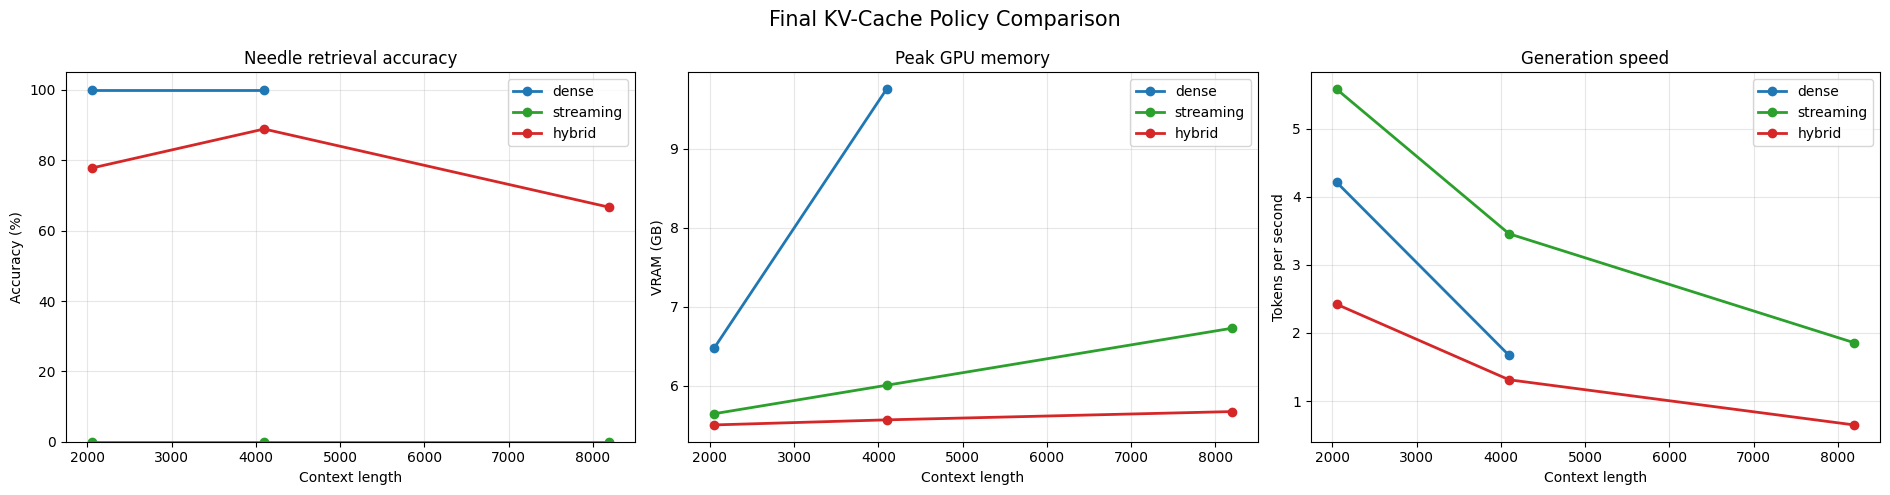


Explainable comparison

Context length: 2048 tokens
dense: accuracy=100.0%, memory=6.47 GB, speed=4.22 tok/s
streaming: accuracy=0.0%, memory=5.65 GB, speed=5.59 tok/s
hybrid: accuracy=77.8%, memory=5.50 GB, speed=2.42 tok/s
Hybrid versus dense memory: -15.0%
Hybrid versus dense retrieval: -22.2 percentage points
Hybrid versus StreamingLLM retrieval: +77.8 percentage points

Context length: 4096 tokens
dense: accuracy=100.0%, memory=9.75 GB, speed=1.67 tok/s
streaming: accuracy=0.0%, memory=6.01 GB, speed=3.46 tok/s
hybrid: accuracy=88.9%, memory=5.57 GB, speed=1.31 tok/s
Hybrid versus dense memory: -42.9%
Hybrid versus dense retrieval: -11.1 percentage points
Hybrid versus StreamingLLM retrieval: +88.9 percentage points

Context length: 8192 tokens
streaming: accuracy=0.0%, memory=6.73 GB, speed=1.86 tok/s
hybrid: accuracy=66.7%, memory=5.67 GB, speed=0.65 tok/s
Hybrid versus StreamingLLM retrieval: +66.7 percentage points

Out-of-memory cases


,mode,sample_id,context_length,depth_name
18,dense,8192_early_42,8192,early
19,dense,8192_early_43,8192,early
20,dense,8192_early_44,8192,early
21,dense,8192_middle_42,8192,middle
22,dense,8192_middle_43,8192,middle
23,dense,8192_middle_44,8192,middle
24,dense,8192_late_42,8192,late
25,dense,8192_late_43,8192,late
26,dense,8192_late_44,8192,late



Saved files:
policy_definitions.csv
all_experiment_results.csv
final_result_summary.csv
retrieval_by_depth.csv
Final report complete


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


required_tables = [
    "DENSE_RESULTS_DF",
    "STREAMING_RESULTS_DF",
    "HYBRID_RESULTS_DF",
]

missing_tables = [
    table_name
    for table_name in required_tables
    if table_name not in globals()
]

if missing_tables:
    raise RuntimeError(
        "The following result tables are missing: "
        f"{missing_tables}. "
        "Run the corresponding benchmark before Step 12."
    )


def find_existing_column(
    dataframe,
    possible_names,
):
    for column_name in possible_names:
        if column_name in dataframe.columns:
            return column_name

    return None


def standardize_results(
    dataframe,
    mode_name,
):
    dataframe = dataframe.copy()

    context_column = find_existing_column(
        dataframe,
        [
            "context_length",
            "actual_context_length",
        ],
    )

    retrieval_column = find_existing_column(
        dataframe,
        [
            "retrieval_correct",
            "exact_match",
        ],
    )

    memory_column = find_existing_column(
        dataframe,
        [
            "peak_memory_gb",
            "generation_peak_memory_gb",
        ],
    )

    speed_column = find_existing_column(
        dataframe,
        [
            "tokens_per_second",
            "generation_tokens_per_second",
        ],
    )

    required_source_columns = {
        "context_length": context_column,
        "retrieval_correct": retrieval_column,
        "peak_memory_gb": memory_column,
        "tokens_per_second": speed_column,
    }

    missing_source_columns = [
        target_name
        for target_name, source_name
        in required_source_columns.items()
        if source_name is None
    ]

    if missing_source_columns:
        raise RuntimeError(
            f"{mode_name} results are missing required "
            f"columns: {missing_source_columns}. "
            f"Available columns are: "
            f"{list(dataframe.columns)}"
        )

    dataframe["context_length"] = (
        dataframe[context_column]
    )

    dataframe["retrieval_correct"] = (
        dataframe[retrieval_column]
    )

    dataframe["peak_memory_gb"] = (
        dataframe[memory_column]
    )

    dataframe["tokens_per_second"] = (
        dataframe[speed_column]
    )

    dataframe["mode"] = mode_name

    dataframe["retrieval_correct"] = (
        dataframe["retrieval_correct"]
        .fillna(False)
        .astype(bool)
    )

    dataframe["context_length"] = pd.to_numeric(
        dataframe["context_length"],
        errors="coerce",
    )

    dataframe["peak_memory_gb"] = pd.to_numeric(
        dataframe["peak_memory_gb"],
        errors="coerce",
    )

    dataframe["tokens_per_second"] = pd.to_numeric(
        dataframe["tokens_per_second"],
        errors="coerce",
    )

    return dataframe[
        [
            "sample_id",
            "mode",
            "status",
            "context_length",
            "depth_name",
            "retrieval_correct",
            "peak_memory_gb",
            "tokens_per_second",
        ]
    ]


DENSE_FINAL_DF = standardize_results(
    DENSE_RESULTS_DF,
    "dense",
)

STREAMING_FINAL_DF = standardize_results(
    STREAMING_RESULTS_DF,
    "streaming",
)

HYBRID_FINAL_DF = standardize_results(
    HYBRID_RESULTS_DF,
    "hybrid",
)


ALL_RESULTS_DF = pd.concat(
    [
        DENSE_FINAL_DF,
        STREAMING_FINAL_DF,
        HYBRID_FINAL_DF,
    ],
    ignore_index=True,
)


POLICY_TABLE = pd.DataFrame(
    [
        {
            "mode": "dense",
            "cache_policy": (
                "Full KV history for every KV group"
            ),
            "purpose": (
                "Quality and memory reference"
            ),
        },
        {
            "mode": "streaming",
            "cache_policy": (
                "Sink tokens plus recent tokens"
            ),
            "purpose": (
                "StreamingLLM baseline"
            ),
        },
        {
            "mode": "hybrid",
            "cache_policy": (
                "Full retrieval groups plus "
                "sink/recent streaming groups"
            ),
            "purpose": (
                "DuoAttention-style hybrid"
            ),
        },
    ]
)


print("Experiment policies")
display(POLICY_TABLE)


STATUS_SUMMARY = (
    ALL_RESULTS_DF
    .groupby(
        [
            "mode",
            "status",
        ],
        as_index=False,
    )
    .agg(
        samples=("sample_id", "count")
    )
)


print()
print("Execution status")
display(STATUS_SUMMARY)


COMPLETED_RESULTS_DF = ALL_RESULTS_DF[
    ALL_RESULTS_DF["status"] == "completed"
].copy()


if COMPLETED_RESULTS_DF.empty:
    raise RuntimeError(
        "There are no completed results to summarize."
    )


RESULT_SUMMARY_DF = (
    COMPLETED_RESULTS_DF
    .groupby(
        [
            "context_length",
            "mode",
        ],
        as_index=False,
    )
    .agg(
        completed_samples=(
            "sample_id",
            "count",
        ),
        retrieval_accuracy=(
            "retrieval_correct",
            "mean",
        ),
        average_peak_memory_gb=(
            "peak_memory_gb",
            "mean",
        ),
        maximum_peak_memory_gb=(
            "peak_memory_gb",
            "max",
        ),
        average_tokens_per_second=(
            "tokens_per_second",
            "mean",
        ),
    )
)


RESULT_SUMMARY_DF[
    "retrieval_accuracy_percent"
] = (
    RESULT_SUMMARY_DF[
        "retrieval_accuracy"
    ]
    * 100
)


print()
print("Results by context length")
display(
    RESULT_SUMMARY_DF[
        [
            "context_length",
            "mode",
            "completed_samples",
            "retrieval_accuracy_percent",
            "average_peak_memory_gb",
            "maximum_peak_memory_gb",
            "average_tokens_per_second",
        ]
    ]
)


DEPTH_SUMMARY_DF = (
    COMPLETED_RESULTS_DF
    .groupby(
        [
            "context_length",
            "depth_name",
            "mode",
        ],
        as_index=False,
    )
    .agg(
        samples=("sample_id", "count"),
        retrieval_accuracy=(
            "retrieval_correct",
            "mean",
        ),
    )
)


DEPTH_SUMMARY_DF[
    "retrieval_accuracy_percent"
] = (
    DEPTH_SUMMARY_DF[
        "retrieval_accuracy"
    ]
    * 100
)


print()
print("Retrieval accuracy by depth")
display(
    DEPTH_SUMMARY_DF[
        [
            "context_length",
            "depth_name",
            "mode",
            "samples",
            "retrieval_accuracy_percent",
        ]
    ]
)


MODE_ORDER = [
    "dense",
    "streaming",
    "hybrid",
]


COLORS = {
    "dense": "#1f77b4",
    "streaming": "#2ca02c",
    "hybrid": "#d62728",
}


fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5),
)


fig.suptitle(
    "Final KV-Cache Policy Comparison",
    fontsize=15,
)


for mode in MODE_ORDER:
    mode_data = RESULT_SUMMARY_DF[
        RESULT_SUMMARY_DF["mode"] == mode
    ].sort_values("context_length")

    if mode_data.empty:
        continue

    axes[0].plot(
        mode_data["context_length"],
        mode_data[
            "retrieval_accuracy_percent"
        ],
        marker="o",
        linewidth=2,
        label=mode,
        color=COLORS[mode],
    )

    axes[1].plot(
        mode_data["context_length"],
        mode_data[
            "average_peak_memory_gb"
        ],
        marker="o",
        linewidth=2,
        label=mode,
        color=COLORS[mode],
    )

    axes[2].plot(
        mode_data["context_length"],
        mode_data[
            "average_tokens_per_second"
        ],
        marker="o",
        linewidth=2,
        label=mode,
        color=COLORS[mode],
    )


axes[0].set_title(
    "Needle retrieval accuracy"
)
axes[0].set_xlabel(
    "Context length"
)
axes[0].set_ylabel(
    "Accuracy (%)"
)
axes[0].set_ylim(
    0,
    105,
)
axes[0].grid(
    alpha=0.3
)
axes[0].legend()


axes[1].set_title(
    "Peak GPU memory"
)
axes[1].set_xlabel(
    "Context length"
)
axes[1].set_ylabel(
    "VRAM (GB)"
)
axes[1].grid(
    alpha=0.3
)
axes[1].legend()


axes[2].set_title(
    "Generation speed"
)
axes[2].set_xlabel(
    "Context length"
)
axes[2].set_ylabel(
    "Tokens per second"
)
axes[2].grid(
    alpha=0.3
)
axes[2].legend()


plt.tight_layout()
plt.show()


print()
print("Explainable comparison")


for context_length in sorted(
    RESULT_SUMMARY_DF[
        "context_length"
    ].dropna().unique()
):
    context_data = RESULT_SUMMARY_DF[
        RESULT_SUMMARY_DF["context_length"]
        == context_length
    ]

    print()
    print(
        f"Context length: "
        f"{int(context_length)} tokens"
    )

    for mode in MODE_ORDER:
        mode_data = context_data[
            context_data["mode"] == mode
        ]

        if mode_data.empty:
            continue

        row = mode_data.iloc[0]

        print(
            f"{mode}: "
            f"accuracy="
            f"{row['retrieval_accuracy_percent']:.1f}%, "
            f"memory="
            f"{row['average_peak_memory_gb']:.2f} GB, "
            f"speed="
            f"{row['average_tokens_per_second']:.2f} tok/s"
        )

    dense_data = context_data[
        context_data["mode"] == "dense"
    ]

    streaming_data = context_data[
        context_data["mode"] == "streaming"
    ]

    hybrid_data = context_data[
        context_data["mode"] == "hybrid"
    ]

    if (
        not dense_data.empty
        and not hybrid_data.empty
    ):
        dense_row = dense_data.iloc[0]
        hybrid_row = hybrid_data.iloc[0]

        dense_memory = (
            dense_row[
                "average_peak_memory_gb"
            ]
        )

        hybrid_memory = (
            hybrid_row[
                "average_peak_memory_gb"
            ]
        )

        if (
            pd.notna(dense_memory)
            and dense_memory > 0
            and pd.notna(hybrid_memory)
        ):
            memory_change = (
                (
                    hybrid_memory
                    / dense_memory
                )
                - 1
            ) * 100

            print(
                f"Hybrid versus dense memory: "
                f"{memory_change:+.1f}%"
            )

        retrieval_difference = (
            hybrid_row[
                "retrieval_accuracy_percent"
            ]
            - dense_row[
                "retrieval_accuracy_percent"
            ]
        )

        print(
            f"Hybrid versus dense retrieval: "
            f"{retrieval_difference:+.1f} "
            f"percentage points"
        )

    if (
        not streaming_data.empty
        and not hybrid_data.empty
    ):
        streaming_row = streaming_data.iloc[0]
        hybrid_row = hybrid_data.iloc[0]

        retrieval_gain = (
            hybrid_row[
                "retrieval_accuracy_percent"
            ]
            - streaming_row[
                "retrieval_accuracy_percent"
            ]
        )

        print(
            f"Hybrid versus StreamingLLM retrieval: "
            f"{retrieval_gain:+.1f} "
            f"percentage points"
        )


OOM_RESULTS_DF = ALL_RESULTS_DF[
    ALL_RESULTS_DF["status"] == "out_of_memory"
].copy()


if not OOM_RESULTS_DF.empty:
    print()
    print("Out-of-memory cases")

    display(
        OOM_RESULTS_DF[
            [
                "mode",
                "sample_id",
                "context_length",
                "depth_name",
            ]
        ]
    )


POLICY_TABLE.to_csv(
    "policy_definitions.csv",
    index=False,
)

ALL_RESULTS_DF.to_csv(
    "all_experiment_results.csv",
    index=False,
)

RESULT_SUMMARY_DF.to_csv(
    "final_result_summary.csv",
    index=False,
)

DEPTH_SUMMARY_DF.to_csv(
    "retrieval_by_depth.csv",
    index=False,
)


print()
print("Saved files:")
print("policy_definitions.csv")
print("all_experiment_results.csv")
print("final_result_summary.csv")
print("retrieval_by_depth.csv")
print("Final report complete")